# Hệ thống AI tư vấn đặt món — tài liệu giảng dạy và báo cáo

**Đồ án:** trợ lý AI trong ứng dụng gọi món qua mã QR tại bàn
**Dữ liệu:** thực đơn 91 món, 13 nhóm · **Mô hình:** `cx/gpt-5.6-luna-review` qua 9router
**Môi trường:** Python 3.12, CPU

---

> **Cam kết về số liệu.** Mọi con số trong notebook này được **tính trực tiếp** từ mã và dữ
> liệu thật của dự án khi bạn chạy ô mã. Không có bảng nào chép tay, không có ảnh chụp sẵn.
> Chạy lại notebook là đo lại từ đầu.

## Notebook này dạy gì

Notebook đi theo **đúng thứ tự mà hệ thống đã được xây**, vì thứ tự đó chính là phương pháp.
Mỗi phần có ba lớp:

| Lớp | Nội dung |
|---|---|
| **Kiến thức** | khái niệm, vì sao nó cần, và cái bẫy thường gặp |
| **Ví dụ tại dự án** | ô mã chạy trên dữ liệu thật, in ra số |
| **Nhận xét** | quan sát → diễn giải → giới hạn → quyết định tiếp theo |

## Mục lục — và ai phụ trách phần nào

Nhóm 5 người chia việc thành **một vai nền tảng cộng bốn khâu của pipeline**:

```
        TV1  NỀN TẢNG — dữ liệu & đo lường
             kho tri thức · từ điển nhãn · tập đánh giá · thước đo
             KHÔNG phải một chặng runtime: mọi khâu DÙNG nó, không đi qua
                          │
                          ▼  cung cấp dữ liệu và tiêu chí cho cả 4 khâu
khách gõ câu → TV5 cổng vào & phiên → TV2 hiểu câu hỏi → TV3 truy hồi
             → TV4 chọn món & giỏ hàng → TV5 ghi bộ nhớ, trả JSON
```

| TV | Phụ trách | Module sở hữu | Mục notebook | Trạng thái |
|---|---|---|---|---|
| **1** | **Nền tảng: dữ liệu & đo lường** | `knowledge/*` · `chunker.py` · `build_*.py` · `evaluation/*` | 1–11, 14–15 | **xong phần hiện có** |
| **2** | Hiểu câu hỏi | `understand.py` · `llm_understand.py` | 4, 12–13, 16 | **xong** |
| **3** | Truy hồi | `rag/bm25.py` · `embedding.py` · `hybrid.py` | 15 | **chưa có** |
| **4** | Chọn món & giỏ hàng | `answer.py` · `cart.py` | 12–14 | **xong** |
| **5** | Cổng vào & phiên | `service.py` · `session.py` | 16 (một phần) | **xong mã**, chưa chạy thật |
| — | Kết quả, hạn chế, hướng phát triển | — | 17–19 | — |

**Vì sao dữ liệu và đo lường thuộc CÙNG một người.** Chúng giống nhau ở điểm quan trọng nhất: cả
hai **không phải chặng runtime** — một câu hỏi không "đi qua" từ điển nhãn hay tập đánh giá, nó
*dùng* chúng. Tách chúng ra thì hoặc chúng bị gửi vào các khâu (và người nhận gánh thêm một nền
kiến thức lạ), hoặc chúng thành "việc chung" và không ai làm.

Chúng cũng đòi **cùng một loại kỷ luật**: *số phải tính được, không được viết tay*. Dự án đã mắc lỗi
đó hai lần và cả hai đều ở phần TV1 phụ trách — `"hơn 90 món"` khi thực đơn có đúng 91, và kiểm kê
đụng chữ ghi `32/90` khi thật là `53/40`.

Nhờ tách như vậy, **TV3 chỉ làm truy hồi** (một nền kiến thức: tf-idf, cosine, chỉ số xếp hạng), và
**đo lường có tên** thay vì thành việc chung.

**Mục notebook không ứng một-một với TV**, và đó là điều phải nói rõ: notebook đi theo thứ tự **học
được** (bài toán → dữ liệu → đo lường → trả lời → truy hồi → mô hình), còn phân công đi theo thứ tự
**chạy**. Hai thứ tự trả lời hai câu hỏi khác nhau — *học thế nào cho hiểu* và *ai sửa tệp nào*.

**Điều phải biết trước: TV1 nằm trên đường tới hạn của hai người.** TV3 không đo được phép so truy
hồi trước khi TV1 xong ~120 ca truy hồi; TV5 không đo được bộ nhớ phiên trước khi TV1 xong ~25 kịch
bản đa lượt. Nên thứ tự tuần 1 của TV1 là **ca đánh giá trước, mở rộng kho sau**.

---
# PHẦN 1 — BÀI TOÁN, DỮ LIỆU VÀ KHO TRI THỨC
> **TV1** — nền tảng dữ liệu

> **Vị trí:** nền tảng của cả pipeline. Không phải một chặng runtime — một câu hỏi không "đi qua"
> từ điển nhãn, nó *dùng* từ điển. Nhưng mọi khâu đều đo trên dữ liệu này.

| | |
|---|---|
| **Câu hỏi khâu này trả lời** | *AI được phép trả lời gì, dữ liệu có gì, và khi một nhãn không có mặt thì kết luận được gì?* |
| **Kiến thức phải nắm** | phân loại ba loại câu hỏi A/B/C · rút dấu tiếng Việt là phép mất thông tin · độ phủ nhãn quyết định filterability · chunking cho truy hồi · provenance `derived` vs `demo` |
| **Tệp sở hữu** | `ai/knowledge/*` · `rag/chunker.py` · `build_knowledge.py` · `build_tag_dictionary.py` · `audit_allergen_tags.py` · `backend/data/menu-tags.json` · `ai/evaluation/*` |
| **Đầu vào** | thực đơn thật (91 món) và yêu cầu nghiệp vụ |
| **Đầu ra bàn giao** | từ điển nhãn có tiền tố nhóm · kho 84 tài liệu / 327 đoạn · `KnowledgeChunk` cho TV3 · 119 ca và thước đo cho cả nhóm |
| **Tự đo bằng** | `build_knowledge.py --check` · `build_tag_dictionary.py --check` · `audit_allergen_tags.py` · `python -m unittest test_chunker test_packaging` |
| **Trạng thái** | **xong** — 103 test xanh, 2 bộ sinh khớp kết quả sinh lại |

### Vì sao khâu này đứng đầu

Phản xạ tự nhiên khi bắt đầu là chọn mô hình hoặc dựng RAG. Cả hai đều **sai thứ tự**, vì cả
hai đều cần một thứ chưa có: **định nghĩa thế nào là trả lời sai**. Không có định nghĩa đó thì
mọi câu trả lời đều "có vẻ hợp lý", và không ai đo được gì.

Bảy mục dưới đây là nội dung TV1 phải hiểu, và mỗi mục có ô mã tính lại từ mã sống —
nên đọc xong chạy được ngay, không phải tin lời.

## 1. Cần làm gì đầu tiên: phát biểu bài toán

### Kiến thức

Câu hỏi tự nhiên khi bắt đầu một hệ thống AI là "dùng mô hình nào" hoặc "dựng RAG thế nào".
Cả hai đều **sai thứ tự**.

Việc đầu tiên là trả lời: **AI này được phép trả lời gì, và tuyệt đối không làm gì.** Lý do
rất cụ thể: nếu chưa định nghĩa được thế nào là *ngoài phạm vi*, thì không thể biết hệ thống
đang trả lời sai — mọi câu trả lời đều "có vẻ hợp lý".

Bản cũ của dự án này được viết trước khi câu hỏi đó được trả lời rõ. Kết quả đo được: **8
đường xử lý chồng nhau**, và **2 trong số đó bị một cờ tắt mà hệ thống vẫn hoạt động đúng** —
tức chúng là dư, nhưng không ai biết vì không có định nghĩa để đối chiếu.

### Ba loại câu hỏi, và đây là phân loại quyết định kiến trúc

| Loại | Ví dụ | Đặc điểm | Ai trả lời |
|---|---|---|---|
| **A — tra cứu thực đơn** | "Phở bò bao nhiêu tiền?" | đáp án nằm sẵn trong dữ liệu | **mã tất định**, không được để mô hình |
| **B — tri thức nhà hàng** | "Mấy giờ mở cửa?" | sự thật đã viết ra, không nằm trong thực đơn | tra kho tri thức |
| **C — phán đoán, diễn đạt** | "Gợi ý món cho 4 người ăn tối" | không có đáp án đúng duy nhất | mô hình sinh có giá trị thật |

**Nguyên tắc phân tuyến:** câu loại A **không được** để mô hình sinh trả lời. Không phải vì
mô hình dở, mà vì tra bảng đúng 100% và tái lập được, còn mô hình không đảm bảo cả hai.

Đây là kiến thức áp dụng được cho mọi hệ thống AI có dữ liệu có cấu trúc: **việc gì tra được
thì đừng suy luận.**

In [1]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

# Ba điều AI tuyệt đối không làm — đọc từ chính tài liệu phát biểu bài toán
doc = (ROOT / "ai" / "docs" / "00-problem-statement.md").read_text(encoding="utf-8")
start = doc.index("**Ba việc AI tuyệt đối không làm**")
print(doc[start:start + 780])

**Ba việc AI tuyệt đối không làm** (giới hạn về quyền, không phải về năng lực):

1. Không tự tạo đơn, không tự thêm món vào giỏ, không tự thanh toán. Mọi đề xuất món
   phải kèm cờ *cần khách xác nhận*.
2. Không khẳng định một món **an toàn** với người dị ứng. Chỉ được nói thực đơn *ghi
   nhận* hoặc *không ghi nhận* thành phần đó, và luôn mở đường hỏi nhân viên. Mô tả
   thực đơn không phải kết quả kiểm tra bếp.
3. Không bịa món, không bịa giá. Mọi món nêu ra phải tồn tại trong thực đơn với đúng
   giá đó.

## 5. Thế nào là trả lời tốt

Định nghĩa này sẽ trở thành thước đo ở bước 3, nên nó phải **đo được**, không phải
cảm nhận.

Một câu trả lời tốt là câu:

1. **Có nội dung** — nêu được món hoặc trả lời được câu hỏi. Câu "bạn muốn gì?" không
   tính là trả lời.
2. **Đú


#### Nhận xét — Mục 1

- **Quan sát:** ba điều cấm không phải giới hạn về *năng lực* mà về *quyền*. Mô hình hoàn
  toàn viết được câu "món này an toàn cho người dị ứng" — vấn đề là nó không có cơ sở để nói.
- **Diễn giải:** phân biệt "không làm được" và "không được phép làm" là phân biệt cốt lõi khi
  thiết kế AI có tác động thật. Điều thứ nhất sẽ hết khi mô hình mạnh hơn; điều thứ hai thì
  không.
- **Giới hạn:** phát biểu bài toán là văn bản, nên nó chỉ có giá trị nếu có cơ chế cưỡng chế.
  Phần V sẽ cho thấy ba điều cấm này được cưỡng chế bằng mã và test như thế nào.
- **Quyết định tiếp theo:** trước khi viết bất kỳ dòng nào, phải hiểu dữ liệu — Mục 2.

## 2. Từ điển dữ liệu: hiểu dữ liệu trước khi dùng

### Kiến thức

Mỗi hệ thống AI có dữ liệu đều cần một **từ điển dữ liệu** trả lời ba câu:

1. Mỗi trường nghĩa là gì?
2. Trường nào là **sự thật** (giá, tên), trường nào là **nhãn do người gán** (đánh giá cảm quan)?
3. **Khi một nhãn không có mặt thì kết luận được điều gì?**

Câu thứ ba là câu quan trọng nhất và hay bị bỏ qua nhất.

### Cái bẫy: rút dấu tiếng Việt làm hai từ khác nghĩa trùng nhau

Khách Việt thường gõ không dấu, nên hệ thống phải rút dấu để khớp. Nhưng rút dấu là phép
**mất thông tin**, và bản cũ dùng chữ đã rút dấu để *quyết định nội dung* — gây **7 lỗi cùng
một gốc**.

Nguyên tắc rút ra: **rút dấu để khớp cách khách gõ, không để quyết định nội dung.**

In [2]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

# Bảy vụ đụng chữ của bản cũ, và cách khóa có không gian tên xoá cả lớp lỗi
import unicodedata

def fold(s):
    s = unicodedata.normalize("NFD", s.lower())
    return "".join(c for c in s if unicodedata.category(c) != "Mn").replace("đ", "d")

# Mỗi dòng: (chuỗi cũ, nghĩa thật, từ nó đụng, khóa mới thay thế nó)
collisions = [
    ("cua",   "con cua",         "của / cửa",   "ingredient:crab"),
    ("chay",  "ăn chay",         "chạy",        "diet:vegetarian"),
    ("trung", "trứng",           "miền Trung",  "allergen:egg"),
    ("bo",    "bơ (nguồn sữa)",  "bò",          "allergen:dairy"),
    ("muc",   "mực",             "mức",         "ingredient:squid"),
    ("lac",   "đậu lạc",         "lắc",         "allergen:peanut"),
    ("tra",   "trà",             "tráng",       "cat_drink (danh mục)"),
]
print("Chiều 1 — sau khi rút dấu, chuỗi cũ có nằm trong từ thông thường không?\n")
print(f"{'chuỗi cũ':8} {'nghĩa thật':17} {'đụng từ':13} nằm trong?")
print("-" * 62)
for old, meaning, clash, _new in collisions:
    print(f"{old:8} {meaning:17} {clash:13} {'CÓ  <-- lỗi' if fold(old) in fold(clash) else 'không'}")

print("\nChiều 2 — khóa mới có thể đụng từ thông thường không?\n")
print(f"{'chuỗi cũ':8} -> {'khóa mới':22} còn đụng?")
print("-" * 62)
for old, _m, clash, new in collisions:
    print(f"{old:8} -> {new:22} {'CÓ' if fold(new) in fold(clash) else 'không'}")

# Chốt bằng số thay vì bằng lời: đếm xem còn vụ đụng nào không.
still = sum(1 for old, _m, clash, new in collisions if fold(new) in fold(clash))
print(f"\nSố vụ đụng chữ còn lại sau khi gán nhãn lại: {still}/{len(collisions)}")

# Ba trong bảy chuỗi cũ không phải NHÃN mà là CỤM TỪ VỰNG trong bộ hiểu câu hỏi.
# Chúng được xử bằng cơ chế khác, nên phải nói rõ chứ không gộp làm một.
d = load("menu-tags.json")
legacy = {e["legacy_key"] for e in d["tags"].values()}
in_tags = [old for old, *_ in collisions if old in legacy]
print(f"\nTrong 7 chuỗi trên, {len(in_tags)} là nhãn thực đơn: {in_tags}")
print(f"{7 - len(in_tags)} còn lại là cụm trong bộ hiểu câu hỏi, xử bằng cơ chế 'ăn hết")
print("đoạn đã khớp' — Phần III sẽ đo giá trị của cơ chế đó.")

Chiều 1 — sau khi rút dấu, chuỗi cũ có nằm trong từ thông thường không?

chuỗi cũ nghĩa thật        đụng từ       nằm trong?
--------------------------------------------------------------
cua      con cua           của / cửa     CÓ  <-- lỗi
chay     ăn chay           chạy          CÓ  <-- lỗi
trung    trứng             miền Trung    CÓ  <-- lỗi
bo       bơ (nguồn sữa)    bò            CÓ  <-- lỗi
muc      mực               mức           CÓ  <-- lỗi
lac      đậu lạc           lắc           CÓ  <-- lỗi
tra      trà               tráng         CÓ  <-- lỗi

Chiều 2 — khóa mới có thể đụng từ thông thường không?

chuỗi cũ -> khóa mới               còn đụng?
--------------------------------------------------------------
cua      -> ingredient:crab        không
chay     -> diet:vegetarian        không
trung    -> allergen:egg           không
bo       -> allergen:dairy         không
muc      -> ingredient:squid       không
lac      -> allergen:peanut        không
tra      -> cat_drink (danh mục

#### Nhận xét — Mục 2

- **Quan sát:** cả 7 nhãn cũ đều là **từ tiếng Việt trần**, nên sau khi rút dấu chúng nằm
  trong từ thông thường. Khóa mới (`ingredient:crab`, `diet:vegetarian`) không có tính chất
  đó — khách không bao giờ gõ chuỗi `ingredient:crab`.
- **Diễn giải:** đây là **sửa cả lớp lỗi bằng cách đổi cấu trúc**, không phải vá từng ca.
  Vá từng ca thì ca thứ tám sẽ xuất hiện; đổi cấu trúc thì không còn ca nào.
- **Giới hạn:** khóa có không gian tên không tự động đúng. Vẫn cần biết `toi` nghĩa là "tối"
  hay "tỏi" — và câu trả lời nằm ở mục tiếp theo.
- **Quyết định tiếp theo:** kiểm chứng nghĩa của nhãn nhập nhằng nhất.

### Cách xác định nghĩa một nhãn nhập nhằng — ví dụ trực tiếp

Nhãn `toi` có trên 64/91 món. Nó là **"tối"** (bữa tối) hay **"tỏi"** (gia vị)? Bản cũ đoán
là "tỏi", và câu "Món nào có tỏi?" trả về 36 món mà chỉ 11 món thật sự có tỏi.

**Phương pháp:** đừng đoán, hãy tìm bằng chứng độc lập. Ô dưới dùng hai nguồn.

In [3]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

# Bằng chứng 1 — phân bố nhãn theo nhóm món. Nếu là "tỏi" thì nhóm ngọt không thể mang nhãn.
menu = load("menu-dataset.json")
items, cats = menu["items"], {c["categoryId"]: c["name"] for c in menu["categories"]}

print("Món mang nhãn (khóa mới `meal:dinner`, khóa cũ `toi`) theo nhóm:\n")
proof = []
for cid, name in cats.items():
    group = [m for m in items if m["categoryId"] == cid]
    with_tag = [m for m in group if "meal:dinner" in m["tags"]]
    has_garlic = [m for m in group if "tỏi" in m["description"].lower()]
    decisive = len(with_tag) == len(group) and not has_garlic
    if decisive:
        proof.append(name)
    mark = "  <-- BẰNG CHỨNG" if decisive else ""
    print(f"  {name:22} {len(with_tag)}/{len(group)} mang nhãn, {len(has_garlic)} món có tỏi{mark}")

# Kết luận sinh từ số đếm, không viết cứng — nếu dữ liệu đổi thì câu này đổi theo.
print(f"\n{len(proof)} nhóm mang nhãn ở MỌI món mà KHÔNG món nào có tỏi: {', '.join(proof)}.")
print("Nếu nhãn nghĩa là 'tỏi' thì điều đó bất khả — nên nhãn nghĩa là 'tối' (bữa tối).")

# Bằng chứng 2 — từ điển nhãn do người làm giao diện viết, đã có trong repo từ trước.
card = (ROOT / "frontend" / "src" / "components" / "menu" / "MenuItemCard.tsx").read_text(encoding="utf-8")
line = next(l for l in card.splitlines() if '"toi"' in l)
print(f"\nBằng chứng 2 — frontend/src/components/menu/MenuItemCard.tsx:\n {line.strip()}")

Món mang nhãn (khóa mới `meal:dinner`, khóa cũ `toi`) theo nhóm:

  Khai vị                4/7 mang nhãn, 0 món có tỏi
  Phở & Bún              2/7 mang nhãn, 0 món có tỏi
  Cơm Việt               4/7 mang nhãn, 3 món có tỏi
  Hải sản                7/7 mang nhãn, 2 món có tỏi
  Lẩu                    7/7 mang nhãn, 0 món có tỏi  <-- BẰNG CHỨNG
  Món gà                 7/7 mang nhãn, 4 món có tỏi
  Đặc sản vùng miền      2/7 mang nhãn, 2 món có tỏi
  Món chay               3/7 mang nhãn, 1 món có tỏi
  Cà phê & Trà           3/7 mang nhãn, 0 món có tỏi
  Nước ép & Sinh tố      4/7 mang nhãn, 0 món có tỏi
  Tráng miệng            7/7 mang nhãn, 0 món có tỏi  <-- BẰNG CHỨNG
  Trái cây tươi          7/7 mang nhãn, 0 món có tỏi  <-- BẰNG CHỨNG
  Bia & Rượu             7/7 mang nhãn, 0 món có tỏi  <-- BẰNG CHỨNG

4 nhóm mang nhãn ở MỌI món mà KHÔNG món nào có tỏi: Lẩu, Tráng miệng, Trái cây tươi, Bia & Rượu.
Nếu nhãn nghĩa là 'tỏi' thì điều đó bất khả — nên nhãn nghĩa là 'tối' (bữa tối).

B

#### Nhận xét — Mục 2 (tiếp)

- **Quan sát:** ô mã đếm ra các nhóm mang nhãn ở **mọi** món mà **0 món** có tỏi — nếu nhãn
  nghĩa là "tỏi" thì điều đó bất khả. Và từ điển của người làm giao diện ghi thẳng
  `"toi": "Tối"`. Hai nguồn độc lập, cùng một kết luận.
- **Diễn giải:** câu trả lời **đã nằm trong repo suốt thời gian đó**. Bài học không phải "cần
  cẩn thận hơn" mà là: tri thức này nằm ở ba nơi tách biệt và **không có gì canh chúng khỏi
  trôi khỏi nhau**.
- **Giới hạn:** phương pháp "tìm bằng chứng độc lập" chỉ dùng được khi có nguồn thứ hai. Với
  nhãn cảm quan như `health:healthy` thì không có nguồn nào đối chiếu.
- **Quyết định tiếp theo:** hợp nhất về một nguồn, và thêm test canh sự trôi.

## 3. Điều quan trọng nhất về nhãn: thiếu nhãn nghĩa là gì

### Kiến thức

Với dữ liệu có nhãn, câu hỏi quyết định an toàn là: **món không mang nhãn X thì kết luận được
gì?** Có hai khả năng hoàn toàn khác nhau:

- **Nhóm phủ hết** (mọi món đều có đúng một giá trị) → thiếu nhãn là **lỗi dữ liệu**, và lọc
  được dứt khoát.
- **Nhóm không phủ hết** → thiếu nhãn nghĩa là **chưa ghi nhận**, *không* phải *không có*.

Lẫn hai trường hợp này là gốc của lỗi an toàn nghiêm trọng nhất trong hệ thống tư vấn ăn uống:
suy ra "món này an toàn" từ việc thiếu nhãn dị nguyên.

In [4]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

# Độ phủ từng nhóm nhãn — con số quyết định nhóm nào lọc được dứt khoát
from collections import defaultdict
menu, d = load("menu-dataset.json"), load("menu-tags.json")
items = menu["items"]
groups = sorted({e["group"] for e in d["tags"].values()})

rows = []
for g in groups:
    covered = len({m["id"] for m in items if any(t.startswith(g + ":") for t in m["tags"])})
    rows.append((covered, g))
rows.sort(reverse=True)

print(f"{'nhóm':12} {'phủ':>8}  thiếu nhãn nghĩa là gì")
print("-" * 68)
for covered, g in rows:
    if covered == len(items):
        verdict = "LỖI DỮ LIỆU -> lọc thẳng được"
    else:
        verdict = "chưa ghi nhận -> KHÔNG kết luận được"
    print(f"{g:12} {covered:>4}/{len(items)}  {verdict}")

allergen = len({m["id"] for m in items if any(t.startswith("allergen:") for t in m["tags"])})
print(f"\nNhóm allergen phủ {allergen}/{len(items)} món.")
print(f"=> {len(items) - allergen} món KHÔNG mang nhãn dị nguyên nào, và điều đó KHÔNG")
print("   cho phép nói chúng không chứa dị nguyên.")

nhóm              phủ  thiếu nhãn nghĩa là gì
--------------------------------------------------------------------
spice          91/91  LỖI DỮ LIỆU -> lọc thẳng được
season         91/91  LỖI DỮ LIỆU -> lọc thẳng được
price          91/91  LỖI DỮ LIỆU -> lọc thẳng được
party          91/91  LỖI DỮ LIỆU -> lọc thẳng được
meal           91/91  LỖI DỮ LIỆU -> lọc thẳng được
occasion       79/91  chưa ghi nhận -> KHÔNG kết luận được
flavour        72/91  chưa ghi nhận -> KHÔNG kết luận được
health         67/91  chưa ghi nhận -> KHÔNG kết luận được
region         65/91  chưa ghi nhận -> KHÔNG kết luận được
method         57/91  chưa ghi nhận -> KHÔNG kết luận được
ingredient     57/91  chưa ghi nhận -> KHÔNG kết luận được
audience       52/91  chưa ghi nhận -> KHÔNG kết luận được
allergen       44/91  chưa ghi nhận -> KHÔNG kết luận được
serving        24/91  chưa ghi nhận -> KHÔNG kết luận được
diet           17/91  chưa ghi nhận -> KHÔNG kết luận được
promo           4/91  chưa ghi nhận

#### Nhận xét — Mục 3

- **Quan sát:** 5 nhóm phủ 91/91 (`meal`, `party`, `price`, `season`, `spice`); nhóm
  `allergen` chỉ phủ 44/91.
- **Diễn giải:** hệ quả trực tiếp cho thiết kế: lọc "không cay" là kết luận được vì `spice`
  phủ hết; còn lọc dị nguyên **phải fail-closed** và **luôn kèm lời nhắc hỏi nhân viên**, vì
  47 món không có nhãn không có nghĩa là an toàn.
- **Giới hạn:** đối chiếu nhãn với mô tả món tìm ra **7 lỗ nhãn dị nguyên thật** (6 món hải
  sản, 1 món gluten). Nhưng mô tả không phải bảng thành phần, nên **còn thiếu bao nhiêu thì
  không biết được từ dữ liệu này** — chỉ nhà hàng trả lời được.
- **Quyết định tiếp theo:** đã hiểu dữ liệu, sang phần đo lường.

## 4. Rút dấu tiếng Việt là phép MẤT thông tin

### Kiến thức

Để khớp câu khách gõ, hệ thống phải **rút dấu**: khách viết `"Không cay"`, `"khong cay"`,
`"ko cay"` đều phải hiểu như nhau. Đó là việc bắt buộc, không tránh được.

Nhưng rút dấu là **hàm không đơn ánh** — hai chuỗi khác nghĩa có thể cho cùng kết quả. Bảy lỗi
của bản cũ đều sinh ra từ đúng chỗ này, và chúng không phải bảy lỗi độc lập: chúng là **một lớp
lỗi** xuất hiện bảy lần.

**Cách sửa không phải sửa từng lỗi.** Sửa từng lỗi thì lỗi thứ tám sẽ tới. Cách sửa là **đổi
hình dạng dữ liệu** để lớp lỗi đó không còn khả năng tồn tại: nhãn mang **tiền tố nhóm**.

| Bản cũ | Bản dựng lại |
|---|---|
| `"nong"` — món nóng hay vị nồng? | `serving:hot` / `spice:hot` |
| `"chay"` — ăn chay hay bán chạy? | `diet:vegetarian` / `promo:popular` |

Sau khi đổi, cụm chữ **vẫn** trùng — nhưng tiền tố phân biệt được, nên trùng **không còn là
lỗi**. Đây là điểm cần hiểu: không phải làm cho lỗi biến mất, mà làm cho **lớp lỗi không còn
khả năng tồn tại**.

Cơ chế thứ hai bảo vệ phần còn lại: **khớp cụm dài trước, rồi ăn hết đoạn đã khớp** (thay đoạn
đã khớp bằng khoảng trắng để nó không khớp lần nữa).

In [5]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

# 1) Rút dấu làm MẤT thông tin — chứng minh bằng chính hàm hệ thống dùng
from understand import VOCAB, fold, understand
from collections import defaultdict

menu, d = load("menu-dataset.json"), load("menu-tags.json")
items = menu["items"]

print("Hai chữ khác nghĩa, sau khi rút dấu thành một:")
for a, b in [("nóng", "nồng"), ("chay", "cháy"), ("mực", "mức"), ("tôi", "tỏi")]:
    dau = "  <-- ĐỤNG NHAU" if fold(a) == fold(b) else ""
    print(f"   {a!r:8} -> {fold(a)!r:8}   {b!r:8} -> {fold(b)!r:8}{dau}")

# 2) Nhãn mang tiền tố nhóm: cụm chữ vẫn trùng, nhưng không còn là lỗi
col = defaultdict(set)
for tag in d["tags"]:
    col[fold(tag.split(":", 1)[1].replace("_", " "))].add(tag)
clash = {k: sorted(v) for k, v in col.items() if len(v) > 1}
print(f"\nCụm chữ rút dấu còn trùng giữa các nhãn: {len(clash)}")
for k, v in clash.items():
    print(f"   {k!r} <- {v}   (tiền tố nhóm phân biệt được -> KHÔNG còn là lỗi)")

# 3) Kiểm kê chỗ có nguy cơ — tính lại, không viết tay
phrases = sorted(VOCAB)
names = [fold(m["name"]) for m in items]
in_other = {a for a in phrases for b in phrases if a != b and a in b}
in_name = {p for p in phrases if any(p in n for n in names)}
print(f"\nKiểm kê trên {len(phrases)} cụm từ vựng và {len(items)} tên món:")
print(f"   bị chứa trong cụm từ vựng khác : {len(in_other)}")
print(f"   nằm trong tên món              : {len(in_name)}")
print(f"   thuộc cả hai                   : {len(in_other & in_name)}")
print(f"   TỔNG cụm có nguy cơ            : {len(in_other | in_name)}")

# 4) Cơ chế chặn, thử trên 4 câu từng làm bản cũ sai
print("\nBốn câu từng làm bản cũ sai:")
for q in ["Món nào bán chạy nhất?", "Có đặc sản miền Trung không?",
          "Nhà hàng mấy giờ mở cửa?", "Gà nướng mật ong giá bao nhiêu?"]:
    r = understand(q, items)
    print(f"   {q}")
    print(f"      require={r.require_tags}  avoid={r.avoid_tags}  "
          f"topic={r.policy_topic}  món={r.named_items}")

Hai chữ khác nghĩa, sau khi rút dấu thành một:
   'nóng'   -> 'nong'     'nồng'   -> 'nong'    <-- ĐỤNG NHAU
   'chay'   -> 'chay'     'cháy'   -> 'chay'    <-- ĐỤNG NHAU
   'mực'    -> 'muc'      'mức'    -> 'muc'     <-- ĐỤNG NHAU
   'tôi'    -> 'toi'      'tỏi'    -> 'toi'     <-- ĐỤNG NHAU

Cụm chữ rút dấu còn trùng giữa các nhãn: 1
   'hot' <- ['serving:hot', 'spice:hot']   (tiền tố nhóm phân biệt được -> KHÔNG còn là lỗi)

Kiểm kê trên 427 cụm từ vựng và 91 tên món:
   bị chứa trong cụm từ vựng khác : 66
   nằm trong tên món              : 40
   thuộc cả hai                   : 21
   TỔNG cụm có nguy cơ            : 85

Bốn câu từng làm bản cũ sai:
   Món nào bán chạy nhất?
      require=['promo:popular']  avoid=[]  topic=None  món=[]
   Có đặc sản miền Trung không?
      require=['region:central']  avoid=[]  topic=None  món=[]
   Nhà hàng mấy giờ mở cửa?
      require=[]  avoid=[]  topic=hours  món=[]
   Gà nướng mật ong giá bao nhiêu?
      require=[]  avoid=[]  topic=None  món

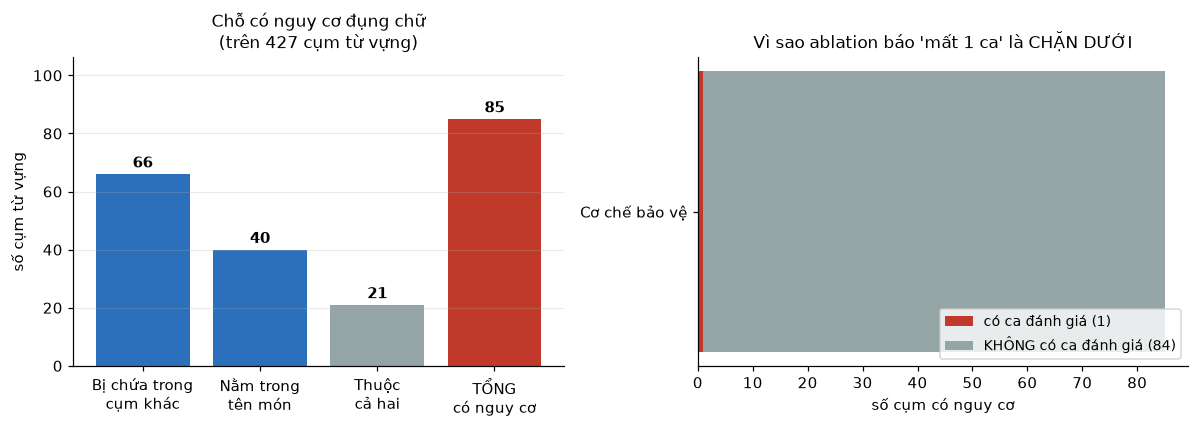

Cơ chế ăn đoạn bảo vệ 85 chỗ; tập đánh giá chỉ chạm tới 1.
=> Con số ablation đo được GIỚI HẠN CỦA TẬP ĐÁNH GIÁ, không đo giá trị cơ chế.


In [6]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

import matplotlib

# KHÔNG đặt backend khi đang ở trong Jupyter. Trong notebook, backend mặc định là `inline` và
# nó nhúng hình PNG vào ô kết quả; ép sang "Agg" thì `plt.show()` chạy im lặng và notebook
# **không có hình nào** — đã mắc đúng lỗi này một lần, 16/16 ô chạy sạch mà 0 biểu đồ.
try:
    get_ipython()                # chỉ tồn tại trong Jupyter
except NameError:
    matplotlib.use("Agg")        # chạy ngoài notebook thì không mở cửa sổ
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.family": "DejaVu Sans",     # có dấu tiếng Việt
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
# Bảng màu dùng chung cả notebook, để biểu đồ trong báo cáo nhất quán.
XANH, DO, XAM, CAM = "#2c6fbb", "#c0392b", "#95a5a6", "#e67e22"

# Biểu đồ 1 — quy mô lớp lỗi đụng chữ, và phần tập đánh giá phủ được
from understand import VOCAB, fold
menu = load("menu-dataset.json"); items = menu["items"]
phrases = sorted(VOCAB); names = [fold(m["name"]) for m in items]
in_other = {a for a in phrases for b in phrases if a != b and a in b}
in_name = {p for p in phrases if any(p in n for n in names)}
rui_ro = in_other | in_name

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

nhan = ["Bị chứa trong\ncụm khác", "Nằm trong\ntên món", "Thuộc\ncả hai", "TỔNG\ncó nguy cơ"]
gia_tri = [len(in_other), len(in_name), len(in_other & in_name), len(rui_ro)]
mau = [XANH, XANH, XAM, DO]
b = ax1.bar(nhan, gia_tri, color=mau)
ax1.bar_label(b, padding=2, fontsize=10, fontweight="bold")
ax1.set_ylabel("số cụm từ vựng")
ax1.set_title(f"Chỗ có nguy cơ đụng chữ\n(trên {len(phrases)} cụm từ vựng)", fontsize=11)
ax1.set_ylim(0, max(gia_tri) * 1.25)

# Ablation đo "mất 1 ca" — nhưng cơ chế bảo vệ 61 chỗ. Đây là khoảng trống của TẬP ĐÁNH GIÁ.
co_ca, khong_ca = 1, len(rui_ro) - 1
ax2.barh(["Cơ chế bảo vệ"], [co_ca], color=DO, label=f"có ca đánh giá ({co_ca})")
ax2.barh(["Cơ chế bảo vệ"], [khong_ca], left=[co_ca], color=XAM,
         label=f"KHÔNG có ca đánh giá ({khong_ca})")
ax2.set_xlabel("số cụm có nguy cơ")
ax2.set_title("Vì sao ablation báo 'mất 1 ca' là CHẶN DƯỚI", fontsize=11)
ax2.legend(loc="lower right", fontsize=9)
ax2.grid(False)

plt.tight_layout()
plt.show()
print(f"Cơ chế ăn đoạn bảo vệ {len(rui_ro)} chỗ; tập đánh giá chỉ chạm tới 1.")
print("=> Con số ablation đo được GIỚI HẠN CỦA TẬP ĐÁNH GIÁ, không đo giá trị cơ chế.")

#### Nhận xét — Mục 4

- **Quan sát:** 4/4 cặp chữ thử đều đụng nhau sau khi rút dấu. Sau khi nhãn mang tiền tố nhóm,
  chỉ còn **1 cụm trùng** (`hot` của `serving:hot` và `spice:hot`) và tiền tố phân biệt được nên
  nó **không còn là lỗi**. Kiểm kê: **85 cụm có nguy cơ** (66 bị chứa trong cụm khác, 40 nằm
  trong tên món, 21 thuộc cả hai).
- **Diễn giải:** đây là ví dụ rõ nhất của nguyên tắc *sửa cấu trúc thay vì sửa lỗi*. Bảy lỗi bản
  cũ là **một lớp lỗi** xuất hiện bảy lần; đổi hình dạng nhãn xóa cả lớp, còn sửa từng lỗi thì
  không bao giờ hết.
- **Giới hạn phải nói ra:** ablation báo cơ chế ăn đoạn "chỉ đáng 1 ca", nhưng nó bảo vệ 61 chỗ.
  Chênh lệch đó là **khoảng trống của tập đánh giá**, không phải bằng chứng cơ chế vô dụng. Đã
  lấp bằng 9 test riêng, và ba con số trên **được tính lại mỗi lần chạy test** —
  `test_understand.collision_census()`. Bản trước của tài liệu ghi "32 cụm" và "90 cụm": hai số
  đó đúng lúc đo, rồi từ vựng lớn lên mà không ai tính lại. Con số hiện tại cũng đã đổi một lần
  nữa (61 → 72) khi từ vựng thêm 20 cụm tên món cho nhóm dị nguyên — và lần này **test đỏ báo
  ngay**, đúng như nó được viết ra để làm.
- **Quyết định tiếp theo:** dữ liệu nhãn đã an toàn, sang phần tri thức không nằm trong nhãn.

## 5. Kho tri thức: MỘT kho, HAI chế độ trả lời

### Kiến thức

Nhãn thực đơn trả lời được "món nào không cay". Nó **không** trả lời được "mấy giờ mở cửa" hay
"đặc sản miền Trung là gì". Phần đó cần **kho tri thức**.

Câu hỏi thiết kế đầu tiên: kho đó nên có mấy phần? Dự án này lúc đầu làm **hai kho** — một tệp
JSON tra khóa, và một thư mục markdown cho truy hồi — với lý do *"tra khóa vs truy hồi xếp
hạng"*. **Lý do đó sai**, và đo lại mới thấy: mọi tài liệu markdown đều có đúng một `topic_keys`
nên chúng cũng tra khóa được. Cách *lấy* không phân biệt được gì.

Ranh giới thật là **chế độ trả lời** — mô hình được tin bao nhiêu:

| `answer_mode` | Nội dung tới khách | Dùng cho |
|---|---|---|
| `verbatim` | **nguyên văn**, mô hình không chạm vào chữ | giờ mở cửa, thanh toán, phụ phí, cách khai dị ứng |
| `synthesize` | **đầu vào** cho mô hình viết câu trả lời | "đặc sản miền Trung có gì", "gọi bao nhiêu món cho 6 người" |

Và ranh giới đó **không cần hai kho**. Phải phân biệt hai thứ dễ bị gộp lẫn:

- Số **kho lưu trữ** là chuyện gọn gàng → **gộp được**, và gộp còn xóa được một lớp lỗi: khi
  còn hai kho, chủ đề có ở cả hai thì tài liệu kho thứ hai *không bao giờ tới lượt* mà vẫn
  chiếm chỗ trong chỉ mục truy hồi — im lặng, không lỗi.
- Số **chế độ trả lời** là chuyện an toàn → **không gộp được**. Về `synthesize` thì "mấy giờ
  đóng cửa" do mô hình viết và nó *có thể* viết 22h30. Về `verbatim` thì phải nén danh sách
  nhiều món kèm ghi chú dị nguyên vào một câu viết tay.

In [7]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

# Kho tri thức: quy mô, hai chế độ, và điều mỗi chế độ đảm bảo
from collections import Counter
from rag.chunker import (VERBATIM, all_chunks, load_all, retrievable_chunks,
                         verbatim_answers)

docs = load_all(KNOWLEDGE)
chunks = all_chunks(KNOWLEDGE)
print(f"tài liệu                 : {len(docs)}")
print(f"đoạn (chunk)             : {len(chunks)}")
print(f"đoạn ĐƯỢC xếp hạng       : {len(retrievable_chunks(KNOWLEDGE))}")
print(f"theo chế độ trả lời      : {dict(Counter(d.answer_mode for d in docs))}")
print(f"theo nguồn tri thức      : {dict(Counter(d.source for d in docs))}")
print(f"theo thư mục             : {dict(Counter(d.path.parent.name for d in docs))}")

print("\n--- Một tài liệu `verbatim`: chuỗi này tới khách NGUYÊN VĂN ---")
hours = next(d for d in docs if "hours" in d.topic_keys)
print(f"   {hours.verbatim_answer}")

print("\n--- Một đoạn `synthesize`: đây là ĐẦU VÀO cho mô hình viết ---")
ch = next(c for c in retrievable_chunks(KNOWLEDGE) if "region.central" in c.doc_id)
print("   " + ch.text.replace("\n", "\n   ")[:260])

print("\n--- Ranh giới được ÉP, không phải quy ước ---")
syn = next(d for d in docs if d.answer_mode != VERBATIM)
try:
    syn.verbatim_answer
    print("   KHÔNG lỗi -> ranh giới hỏng")
except Exception as e:
    print(f"   Gọi verbatim_answer trên tài liệu synthesize -> {type(e).__name__}")
    print(f"   {str(e)[:110]}")

tài liệu                 : 84
đoạn (chunk)             : 327


đoạn ĐƯỢC xếp hạng       : 303
theo chế độ trả lời      : {'synthesize': 60, 'verbatim': 24}
theo nguồn tri thức      : {'derived': 56, 'demo': 28}
theo thư mục             : {'derived': 48, 'policy': 24, 'written': 12}

--- Một tài liệu `verbatim`: chuỗi này tới khách NGUYÊN VĂN ---
   CMC Restaurant mở 10h00–22h00 tất cả các ngày, kể cả cuối tuần và ngày lễ.

--- Một đoạn `synthesize`: đây là ĐẦU VÀO cho mô hình viết ---
   Món miền trung
   Tài liệu này nói về nhóm vùng miền **Miền Trung**. Ẩm thực Việt khác nhau rõ theo vùng. Khách hỏi theo vùng khi muốn ăn đúng đặc sản một nơi, hoặc khi nhớ món quê.

--- Ranh giới được ÉP, không phải quy ước ---
   Gọi verbatim_answer trên tài liệu synthesize -> KnowledgeError
   flavour-fatty.md: chỉ tài liệu `answer_mode: verbatim` có câu trả lời nguyên văn, tài liệu này là 'synthesize'


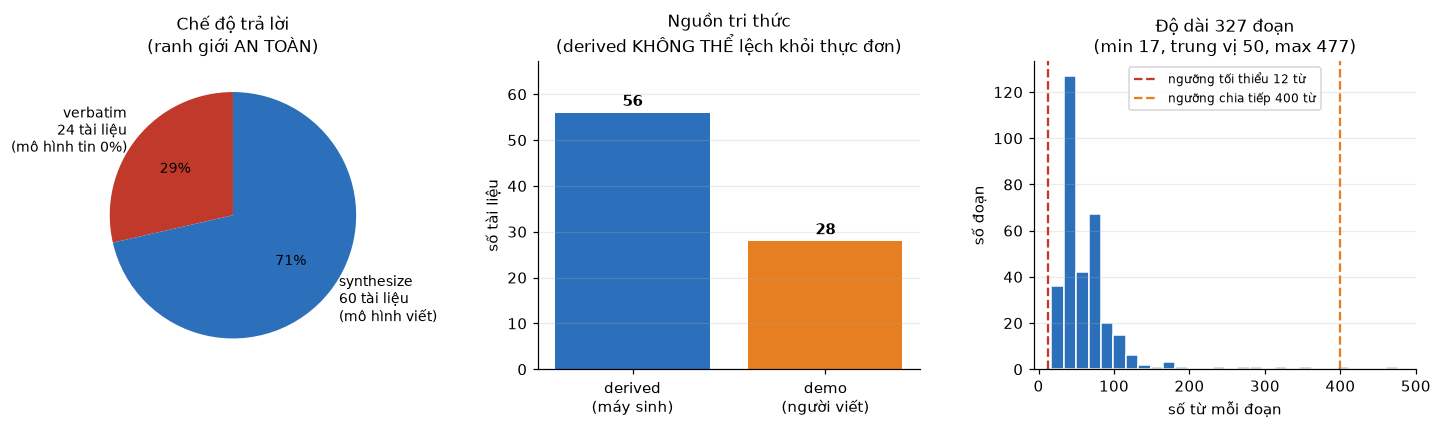

24 đoạn `verbatim` bị LOẠI khỏi chỉ mục truy hồi — chúng đã có đường tới khách
riêng (tra khóa, trả nguyên văn). Để trong chỉ mục là hai đường tới cùng nội dung.


In [8]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

import matplotlib

# KHÔNG đặt backend khi đang ở trong Jupyter. Trong notebook, backend mặc định là `inline` và
# nó nhúng hình PNG vào ô kết quả; ép sang "Agg" thì `plt.show()` chạy im lặng và notebook
# **không có hình nào** — đã mắc đúng lỗi này một lần, 16/16 ô chạy sạch mà 0 biểu đồ.
try:
    get_ipython()                # chỉ tồn tại trong Jupyter
except NameError:
    matplotlib.use("Agg")        # chạy ngoài notebook thì không mở cửa sổ
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.family": "DejaVu Sans",     # có dấu tiếng Việt
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
# Bảng màu dùng chung cả notebook, để biểu đồ trong báo cáo nhất quán.
XANH, DO, XAM, CAM = "#2c6fbb", "#c0392b", "#95a5a6", "#e67e22"

# Biểu đồ 2 — cấu trúc kho tri thức: chế độ trả lời, nguồn, và độ dài đoạn
from collections import Counter
from rag.chunker import all_chunks, load_all, retrievable_chunks

docs = load_all(KNOWLEDGE); chunks = all_chunks(KNOWLEDGE)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13.5, 4))

# (a) chế độ trả lời — mô hình được tin bao nhiêu
mode = Counter(d.answer_mode for d in docs)
ax1.pie([mode["verbatim"], mode["synthesize"]],
        labels=[f"verbatim\n{mode['verbatim']} tài liệu\n(mô hình tin 0%)",
                f"synthesize\n{mode['synthesize']} tài liệu\n(mô hình viết)"],
        colors=[DO, XANH], autopct="%1.0f%%", startangle=90,
        textprops={"fontsize": 9})
ax1.set_title("Chế độ trả lời\n(ranh giới AN TOÀN)", fontsize=11)

# (b) nguồn tri thức — tin được đến đâu
src = Counter(d.source for d in docs)
b = ax2.bar(["derived\n(máy sinh)", "demo\n(người viết)"],
            [src["derived"], src["demo"]], color=[XANH, CAM])
ax2.bar_label(b, padding=2, fontweight="bold")
ax2.set_ylabel("số tài liệu")
ax2.set_title("Nguồn tri thức\n(derived KHÔNG THỂ lệch khỏi thực đơn)", fontsize=11)
ax2.set_ylim(0, max(src.values()) * 1.2)

# (c) phân bố độ dài đoạn — đoạn quá ngắn thì vô dụng khi truy hồi
w = [c.word_count for c in chunks]
ax3.hist(w, bins=28, color=XANH, edgecolor="white")
ax3.axvline(12, color=DO, linestyle="--", linewidth=1.5, label="ngưỡng tối thiểu 12 từ")
ax3.axvline(400, color=CAM, linestyle="--", linewidth=1.5, label="ngưỡng chia tiếp 400 từ")
ax3.set_xlabel("số từ mỗi đoạn"); ax3.set_ylabel("số đoạn")
ax3.set_title(f"Độ dài {len(chunks)} đoạn\n(min {min(w)}, trung vị "
              f"{sorted(w)[len(w)//2]}, max {max(w)})", fontsize=11)
ax3.legend(fontsize=8)

plt.tight_layout(); plt.show()
loai = len(chunks) - len(retrievable_chunks(KNOWLEDGE))
print(f"{loai} đoạn `verbatim` bị LOẠI khỏi chỉ mục truy hồi — chúng đã có đường tới khách")
print("riêng (tra khóa, trả nguyên văn). Để trong chỉ mục là hai đường tới cùng nội dung.")

#### Nhận xét — Mục 5

- **Quan sát:** 84 tài liệu / 327 đoạn trong **một** kho, chia 24 `verbatim` + 60 `synthesize`.
  Bộ truy hồi chỉ xếp hạng **303 đoạn** — 24 đoạn `verbatim` bị loại vì chúng đã có đường tới
  khách riêng.
- **Diễn giải:** hai thứ dễ bị gộp lẫn là **kho lưu trữ** và **chế độ trả lời**. Chúng độc
  lập: không có gì bắt buộc "lưu trong markdown thì phải qua mô hình". Nhận ra điều đó mới gộp
  được kho mà không mất bảo đảm an toàn.
- **Ranh giới được ÉP bằng mã, không phải quy ước:** gọi `verbatim_answer` trên tài liệu
  `synthesize` thì **lỗi**, không phải trả về một chuỗi nào đó. Trả về im lặng thì một chỗ dùng
  sai sẽ đưa nửa tài liệu ra cho khách nguyên văn.
- **Giới hạn:** 28/84 tài liệu là `demo` — giá trị mẫu cho dự án demo. Dùng thật thì chủ nhà
  hàng phải thay, và đổi `source` thành `restaurant` để không còn bị đếm là mẫu.

## 6. Chia đoạn, và cửa `audience: guest`

### Kiến thức

Truy hồi không lấy cả tài liệu, nó lấy **đoạn**. Nên cách chia đoạn quyết định chất lượng truy
hồi trước cả khi chọn phương pháp. Ba quy tắc, mỗi cái một lý do:

1. **Chia theo heading `##`, không theo số ký tự.** Chia theo ký tự thì cắt ngang giữa câu, và
   nửa ý nằm ở đoạn này nửa kia ở đoạn khác — không đoạn nào trả lời được. Heading là ranh giới
   ý nghĩa mà người viết đã đặt sẵn; dùng nó là miễn phí.
2. **Kèm tiêu đề tài liệu vào mỗi đoạn.** Đoạn bị trích ra **rời khỏi** tài liệu. Một đoạn viết
   "Có 7 món, giá từ 189.000đ" mà không nói đang nói về cái gì thì vô dụng.
3. **Gộp đoạn quá ngắn.** Đoạn chỉ có một dòng tiêu đề không mang tín hiệu nào, nhưng **vẫn
   chiếm một chỗ trong top-k** và đẩy một đoạn có ích ra ngoài. Lấy 5 đoạn mà 1 đoạn là rác thì
   thực chất chỉ còn 4.

Chi tiết dễ sai: **gộp phải chạy TRƯỚC khi cấp mã đoạn**. Cấp mã rồi mới gộp thì dãy mã bị
khuyết (`#0, #2, #3`) và tập đánh giá truy hồi trỏ vào mã không tồn tại.

### Cửa `audience`: TỪ CHỐI, không phải lọc bỏ

Bản cũ có 27 tài liệu tri thức, trong đó **5 tài liệu là hướng dẫn cho AI** — phong cách trả
lời, ví dụ phản hồi sai. Cả 27 nằm **cùng một chỉ mục truy hồi**, nên **47/221 đoạn** bị trích
ra cho khách đọc. Khách hỏi giờ mở cửa và nhận một đoạn dạy AI cách xin lỗi.

Có hai cách sửa, và chúng khác nhau nhiều hơn vẻ ngoài:

| Cách | Hôm nay | Tháng sau ai đó thêm tệp nội bộ |
|---|---|---|
| **lọc bỏ** | hết lỗi | tệp **im lặng** bị bỏ qua, người thêm tưởng đã vào kho |
| **từ chối** | hết lỗi | việc thêm **bị chặn ngay**, kèm lý do |

In [9]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

# Ba bất biến của bộ chia đoạn, kiểm trên kho THẬT
from rag.chunker import KnowledgeError, all_chunks, load_all, load_doc
import tempfile
from pathlib import Path as _P

chunks = all_chunks(KNOWLEDGE)
w = sorted(c.word_count for c in chunks)
print(f"Bất biến 1 — mọi đoạn kèm tiêu đề tài liệu : "
      f"{sum(1 for c in chunks if c.text.startswith(c.title))}/{len(chunks)}")
ids = [c.chunk_id for c in chunks]
print(f"Bất biến 2 — chunk_id không trùng          : {len(set(ids))}/{len(ids)}")
print(f"Bất biến 3 — nạp hai lần cho cùng dãy mã   : "
      f"{[c.chunk_id for c in all_chunks(KNOWLEDGE)] == ids}")

khuyet = [d.doc_id for d in load_all(KNOWLEDGE)
          if [int(c.chunk_id.split('#')[1]) for c in d.chunks] != list(range(len(d.chunks)))]
print(f"Bất biến 4 — dãy mã liên tục từ 0          : {len(khuyet)} tài liệu khuyết")
print(f"\nĐộ dài đoạn: min {w[0]}, trung vị {w[len(w)//2]}, max {w[-1]} từ")

# Cửa audience — chứng minh việc TỪ CHỐI thật sự xảy ra
FM = ("id: kb.thu.v1\ntitle: Thử\ntopic_keys: [thu_nghiem]\nsource: demo\n"
      "audience: {aud}\nanswer_mode: synthesize")
BODY = "# Thử\n\n## Mục\n\n" + " ".join(["từ"] * 30)
print("\n--- Cửa audience, thử cả hai chiều ---")
with tempfile.TemporaryDirectory() as tmp:
    for aud in ("guest", "ai"):
        p = _P(tmp) / f"{aud}.md"
        p.write_text(f"---\n{FM.format(aud=aud)}\n---\n\n{BODY}\n", encoding="utf-8")
        try:
            load_doc(p)
            print(f"   audience={aud!r}  -> NHẬN")
        except KnowledgeError as e:
            print(f"   audience={aud!r}     -> TỪ CHỐI")
            print(f"      {str(e)[:105]}...")
print("\nThử chiều ngược là bắt buộc: một bộ nạp từ chối MỌI THỨ cũng qua được")
print("phép kiểm 'từ chối tệp ai'.")

Bất biến 1 — mọi đoạn kèm tiêu đề tài liệu : 327/327
Bất biến 2 — chunk_id không trùng          : 327/327
Bất biến 3 — nạp hai lần cho cùng dãy mã   : True


Bất biến 4 — dãy mã liên tục từ 0          : 0 tài liệu khuyết

Độ dài đoạn: min 17, trung vị 50, max 477 từ

--- Cửa audience, thử cả hai chiều ---
   audience='guest'  -> NHẬN
   audience='ai'     -> TỪ CHỐI
      ai.md: audience='ai' bị từ chối. Kho tri thức chỉ nhận `audience: guest` — nội dung dành cho AI đọc (phon...

Thử chiều ngược là bắt buộc: một bộ nạp từ chối MỌI THỨ cũng qua được
phép kiểm 'từ chối tệp ai'.


#### Nhận xét — Mục 6

- **Quan sát:** 327/327 đoạn kèm tiêu đề tài liệu, 327 mã đoạn không trùng, nạp hai lần cho cùng
  dãy mã, 0 tài liệu có dãy mã khuyết. Cửa `audience` từ chối `ai` và **nhận** `guest`.
- **Diễn giải:** ba bất biến đầu là điều kiện để **tập đánh giá truy hồi tồn tại được**. Mã đoạn
  đổi giữa hai lần sinh thì mọi ca đánh giá trỏ sai chỗ, và người ta sẽ đi sửa bộ truy hồi trong
  khi lỗi nằm ở bộ chia đoạn.
- **Một lỗi thật đã sửa ở đây:** đoạn từng chứa **hai lần** tiêu đề tài liệu (tiền tố `title`
  cộng dòng `# H1` trong thân). Không phải chuyện thẩm mỹ — trùng tiêu đề **thổi phồng tần số
  từ**, và BM25 xếp hạng theo tần số từ. Tức nó làm lệch chính phép so BM25/embedding sẽ chạy ở
  bước sau: **một thiên lệch nằm trong dữ liệu**, nên đọc kết quả sẽ không thấy.
- **Giới hạn:** 3 tài liệu từng sinh ra đoạn mở đầu chỉ có dòng tiêu đề. Đã sửa bằng cách gộp,
  nhưng nó cho thấy bộ chia đoạn **phụ thuộc cách người viết đặt heading** — nên bất biến phải
  do máy canh, không do người nhớ.

## 7. Tri thức kể lại dữ liệu thì phải được SINH, không viết tay

### Kiến thức

Kho tri thức bản cũ có tệp `menu.md` dài 159 dòng, kể lại thực đơn bằng văn xuôi. Trong đó có
câu: *"Nhà hàng có **hơn 90 món**..."* — trong khi thực đơn có **đúng 91 món**.

Câu đó đúng về mặt kỹ thuật nhưng vô dụng, và tệ hơn: nó là **con số viết tay**. Thêm 10 món thì
nó thành sai, và **không ai biết**, vì không có gì canh nó.

Đây là một luật chung, không riêng dự án này:

> **Văn xuôi kể lại dữ liệu thì luôn trôi khỏi dữ liệu.** Dữ liệu đổi, văn không đổi theo.

Chỉ có hai cách xử lý:

| Cách | Đánh giá |
|---|---|
| kỷ luật con người — sửa thực đơn thì sửa cả tài liệu | **luôn thất bại**, vì nó dựa vào việc người ta nhớ |
| **tính lại mỗi lần** — tài liệu do máy sinh, CI kiểm sinh lại được | cách duy nhất chặn được |

Nên `build_knowledge.py` sinh phần `derived`. Con số trong đó không thể sai, vì nó **được tính,
không được viết**.

Phần `demo` là cho nội dung **suy ra không được** ("bia đi với món nướng", "gọi bao nhiêu món cho
4 người"). Nhưng ngay cả phần này, **mọi con số cũng lấy từ thực đơn thật** — nên văn người viết
vẫn không nói sai về dữ liệu được.

### Tiêu chí chọn nhóm để sinh tài liệu

Đáng ra có thể sinh cho cả 16 nhóm nhãn, ra ~120 tài liệu, số nghe to hơn. Chỉ sinh cho **6
nhóm**, theo một tiêu chí duy nhất:

> *Nhóm này có câu hỏi nào mà **lớp tra khóa không trả lời được** không?*

**Có** với `method`, `region`, `ingredient`, `occasion`, `flavour`, `health` → sinh tài liệu.
**Không** với `spice`, `price`, `party`, `season` — bốn nhóm này phủ 91/91 món nên lọc theo nhãn
đã đúng **100%**. Thêm tài liệu là tạo **đường thứ hai cho cùng một việc**, đúng bệnh 8 đường
chồng nhau của bản cũ.

In [10]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

# Chứng minh phần `derived` KHÔNG THỂ lệch: sinh lại rồi so từng byte
import sys as _sys
from collections import Counter
from rag.chunker import load_all
_sys.path.insert(0, str(ROOT / "ai" / "scripts"))
import build_knowledge as bk

docs = load_all(KNOWLEDGE)
src = Counter(d.source for d in docs)
print(f"derived (máy sinh) : {src['derived']} tài liệu")
print(f"demo (người viết)  : {src['demo']} tài liệu")

wanted = bk.generate(load("menu-dataset.json"), load("menu-tags.json"))
khop = sum(1 for p, t in wanted.items()
           if p.exists() and p.read_text(encoding="utf-8-sig") == t)
print(f"\nSinh lại và so từng byte: {khop}/{len(wanted)} tài liệu derived khớp")
print("=> CI chạy `build_knowledge.py --check`, nên tài liệu KHÔNG THỂ trôi khỏi thực đơn.")

# Truy một con số cụ thể về đúng thực đơn
items = load("menu-dataset.json")["items"]
veg = [m for m in items if "diet:vegetarian" in m["tags"]]
doc = next(d for d in docs if "vegetarian" in d.topic_keys)
print(f"\nTruy nguồn một con số:")
print(f"   đếm trực tiếp trên thực đơn : {len(veg)} món chay")
print(f"   tài liệu tri thức nói       : {doc.verbatim_answer[:64]}...")
print(f"   con số {len(veg)} có trong chuỗi     : {str(len(veg)) in doc.verbatim_answer}")

# Tiêu chí chọn nhóm, kiểm bằng độ phủ
d = load("menu-tags.json")
print(f"\nSáu nhóm ĐƯỢC sinh tài liệu: {sorted(bk.DERIVED_GROUPS)}")
print("Bốn nhóm KHÔNG sinh, vì lớp lọc theo nhãn đã đúng 100%:")
for g in ["spice", "price", "party", "season"]:
    phu = len({m["id"] for m in items if any(t.startswith(g + ":") for t in m["tags"])})
    print(f"   {g:8} phủ {phu}/{len(items)} món -> lọc dứt khoát, không cần tài liệu")

derived (máy sinh) : 56 tài liệu
demo (người viết)  : 28 tài liệu

Sinh lại và so từng byte: 56/56 tài liệu derived khớp
=> CI chạy `build_knowledge.py --check`, nên tài liệu KHÔNG THỂ trôi khỏi thực đơn.

Truy nguồn một con số:
   đếm trực tiếp trên thực đơn : 17 món chay
   tài liệu tri thức nói       : Có 17 món chay, và cả 17 món đều là thuần chay — không dùng sữa ...
   con số 17 có trong chuỗi     : True

Sáu nhóm ĐƯỢC sinh tài liệu: ['flavour', 'health', 'ingredient', 'method', 'occasion', 'region']
Bốn nhóm KHÔNG sinh, vì lớp lọc theo nhãn đã đúng 100%:
   spice    phủ 91/91 món -> lọc dứt khoát, không cần tài liệu
   price    phủ 91/91 món -> lọc dứt khoát, không cần tài liệu
   party    phủ 91/91 món -> lọc dứt khoát, không cần tài liệu
   season   phủ 91/91 món -> lọc dứt khoát, không cần tài liệu


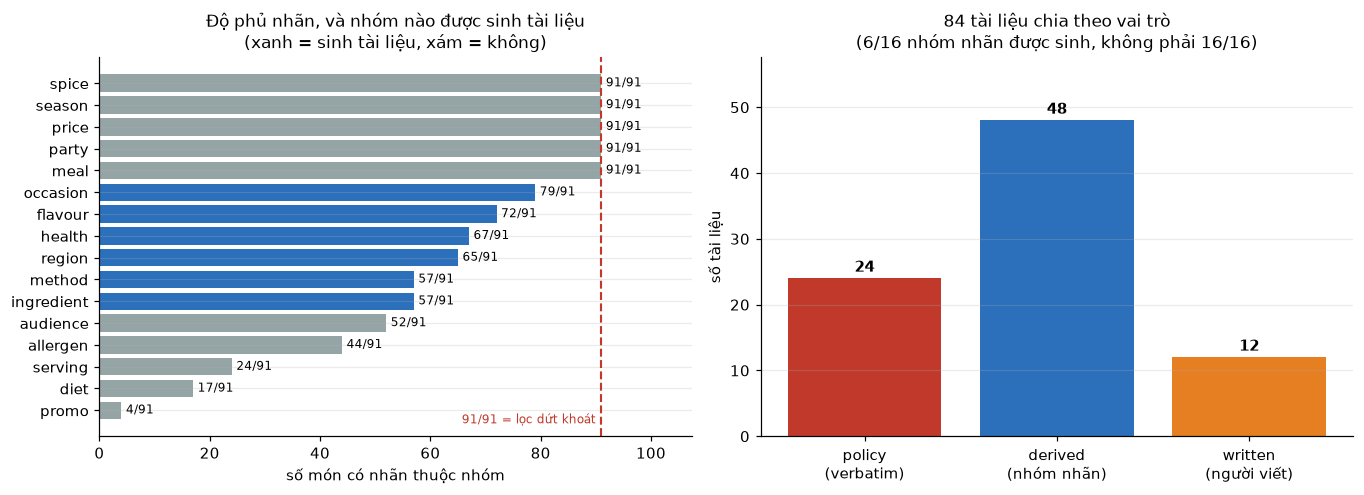

Chỉ 6/16 nhóm nhãn được sinh tài liệu. Tiêu chí: nhóm đó có câu
hỏi nào mà LỚP TRA KHÓA không trả lời được không. Bốn nhóm phủ 91/91 bị bỏ qua vì
lọc theo nhãn đã đúng 100% — thêm tài liệu là tạo đường thứ hai cho cùng một việc.


In [11]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

import matplotlib

# KHÔNG đặt backend khi đang ở trong Jupyter. Trong notebook, backend mặc định là `inline` và
# nó nhúng hình PNG vào ô kết quả; ép sang "Agg" thì `plt.show()` chạy im lặng và notebook
# **không có hình nào** — đã mắc đúng lỗi này một lần, 16/16 ô chạy sạch mà 0 biểu đồ.
try:
    get_ipython()                # chỉ tồn tại trong Jupyter
except NameError:
    matplotlib.use("Agg")        # chạy ngoài notebook thì không mở cửa sổ
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.family": "DejaVu Sans",     # có dấu tiếng Việt
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
# Bảng màu dùng chung cả notebook, để biểu đồ trong báo cáo nhất quán.
XANH, DO, XAM, CAM = "#2c6fbb", "#c0392b", "#95a5a6", "#e67e22"

# Biểu đồ 3 — tiêu chí chọn nhóm sinh tài liệu, đặt cạnh độ phủ nhãn
from collections import Counter
from rag.chunker import load_all
import sys as _sys
_sys.path.insert(0, str(ROOT / "ai" / "scripts"))
import build_knowledge as bk

items = load("menu-dataset.json")["items"]
d = load("menu-tags.json")
groups = sorted({e["group"] for e in d["tags"].values()})
sinh = set(bk.DERIVED_GROUPS)

rows = []
for g in groups:
    phu = len({m["id"] for m in items if any(t.startswith(g + ":") for t in m["tags"])})
    rows.append((phu, g, g in sinh))
rows.sort()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

ten = [g for _, g, _ in rows]
phu = [p for p, _, _ in rows]
mau = [XANH if s else XAM for _, _, s in rows]
b = ax1.barh(ten, phu, color=mau)
ax1.bar_label(b, labels=[f"{p}/91" for p in phu], padding=3, fontsize=8)
ax1.axvline(len(items), color=DO, linestyle="--", linewidth=1.4)
ax1.text(len(items) - 1, -0.6, "91/91 = lọc dứt khoát", color=DO, fontsize=8, ha="right")
ax1.set_xlabel("số món có nhãn thuộc nhóm")
ax1.set_title("Độ phủ nhãn, và nhóm nào được sinh tài liệu\n"
              "(xanh = sinh tài liệu, xám = không)", fontsize=11)
ax1.set_xlim(0, len(items) * 1.18)

# Vì sao KHÔNG sinh cho nhóm phủ đủ: sẽ là đường thứ hai cho cùng một việc
docs = load_all(KNOWLEDGE)
thumuc = Counter(d_.path.parent.name for d_ in docs)
nhan = [f"policy\n(verbatim)", f"derived\n(nhóm nhãn)", f"written\n(người viết)"]
gia = [thumuc["policy"], thumuc["derived"], thumuc["written"]]
b2 = ax2.bar(nhan, gia, color=[DO, XANH, CAM])
ax2.bar_label(b2, padding=2, fontweight="bold")
ax2.set_ylabel("số tài liệu")
ax2.set_title(f"84 tài liệu chia theo vai trò\n"
              f"(6/16 nhóm nhãn được sinh, không phải 16/16)", fontsize=11)
ax2.set_ylim(0, max(gia) * 1.2)

plt.tight_layout(); plt.show()
print(f"Chỉ {len(sinh)}/{len(groups)} nhóm nhãn được sinh tài liệu. Tiêu chí: nhóm đó có câu")
print("hỏi nào mà LỚP TRA KHÓA không trả lời được không. Bốn nhóm phủ 91/91 bị bỏ qua vì")
print("lọc theo nhãn đã đúng 100% — thêm tài liệu là tạo đường thứ hai cho cùng một việc.")

#### Nhận xét — Mục 7

- **Quan sát:** 56/84 tài liệu là `derived`, và **56/56 khớp từng byte** khi sinh lại. Con số
  "17 món chay" trong tài liệu truy được về đúng phép đếm trên thực đơn. Chỉ **6/16** nhóm nhãn
  được sinh tài liệu.
- **Diễn giải:** `--check` trong CI là thứ biến "tài liệu không thể lệch" từ một lời hứa thành
  một **bất biến máy canh**. Không có bước đó thì `derived` chỉ là một cái tên.
- **Tiêu chí chọn nhóm là tiêu chí thật, không phải "thêm cho đủ số đoạn":** 4 nhóm phủ 91/91
  bị bỏ qua vì lọc theo nhãn đã đúng 100%. Thêm tài liệu cho chúng là tạo **đường thứ hai cho
  cùng một việc** — và khi câu trả lời sai thì không ai biết đường nào sai. Bản cũ có 8 đường
  chồng nhau, 2 trong số đó bị tắt mà hệ thống vẫn chạy đúng.
- **Giới hạn:** `demo` vẫn là 28 tài liệu người viết. Chúng không thể nói sai về **con số** (số
  lấy từ thực đơn), nhưng có thể nói sai về **chính sách** — và điều đó chỉ chủ nhà hàng biết.
- **Quyết định tiếp theo:** dữ liệu và tri thức đã xong. Nhưng chưa có cách nào biết hệ thống
  trả lời đúng hay sai — đó là Phần II.

---
# PHẦN 2 — TẬP ĐÁNH GIÁ VÀ THƯỚC ĐO
> **TV1** — nền tảng đo lường. Cùng người với Phần 1, và mục dưới nói vì sao.

> **Vị trí:** **xuyên ngang cả 4 khâu runtime**, không phải một chặng — nên nó thuộc TV1 cùng với
> dữ liệu. Phần này chứa **bài học đắt nhất của cả dự án**.

| | |
|---|---|
| **Câu hỏi khâu này trả lời** | *Làm sao biết hệ thống trả lời đúng hay sai — và làm sao biết thước đo của mình đúng?* |
| **Kiến thức phải nắm** | khóa đáp án dạng truy vấn thay vì danh sách · test hai chiều · chia ba nhóm chốt/phát triển/niêm phong · bộ dò lỗ thước đo |
| **Tệp sở hữu** | `ai/evaluation/cases.json` · `answer_metric.py` · `menu_selectors.py` · `validate_cases.py` · `build_split.py` · `probe_metric_holes.py` · `test_answer_metric.py` |
| **Đầu vào** | thực đơn thật (91 món) và yêu cầu nghiệp vụ |
| **Đầu ra bàn giao** | 119 ca / 41 họ · thước đo 37 test · bộ dò lỗ để TV2 và TV4 chạy `run_baseline.py` |
| **Tự đo bằng** | `validate_cases.py` · `build_split.py --check` · `probe_metric_holes.py` · `python -m unittest discover -s ai/evaluation` |
| **Trạng thái** | **xong** — 37 test xanh, bộ dò tìm 0 lỗ |

### Điều TV1 phải hiểu trước tiên

**Thước đo cũng là một phương pháp, và cũng phải chứng minh được mình đúng.** Ở bản cũ, thước
đo sai **3 lần trước khi hệ thống sai**, và cả 3 lần đều sai theo chiều nguy hiểm hơn: **bịa ra
lỗi không có**, khiến người ta đi sửa những thứ vốn đã đúng.

## 8. Vì sao đo lường phải có trước thứ được đo

### Kiến thức

Đây là bài học đắt nhất của dự án này, và nó đo được bằng số.

Bản cũ viết hệ thống trước, dựng thước đo sau. Hệ quả: **thước đo sai 3 lần trước khi hệ
thống sai.** Ba lần đó đều là **bịa ra lỗi không có** — chiều sai nguy hiểm hơn, vì nó khiến
người ta sửa những thứ vốn đã đúng:

| Lần | Thước đo chấm | Thực tế |
|---|---|---|
| 1 | ca so sánh "không có căn cứ" | câu trả lời nêu **đúng** khoảng cách giá hai món |
| 2 | tỷ lệ hỏi lại 43% | câu trả lời **liệt kê món rồi mời thêm** bị đếm là hỏi lại |
| 3 | tra cứu dinh dưỡng "không dùng được" | ca một món, không cần thẻ thêm giỏ |

Và nó còn có một **lỗ**: câu trả lời **rỗng** được tính là "dùng được", vì không dẫn món nào
thì không vi phạm ràng buộc nào. Khi bịt lỗ đó, con số nền tụt từ **0,9960 xuống 0,7368** —
tức 99,6% kia gần như hoàn toàn là ảo.

**Nguyên tắc:** thước đo cũng là một phương pháp, và **cũng phải chứng minh được mình đúng.**

## 9. Khóa đáp án phải kiểm được — dùng truy vấn, không dùng danh sách

### Kiến thức

Cách viết tập đánh giá thông thường là: câu hỏi → danh sách đáp án đúng. Cách đó có một điểm
yếu chết người: **một danh sách viết tay thì không có cách nào kiểm.** Nó luôn "đúng" theo
định nghĩa.

Bản cũ có **96 khóa đáp án trỏ vào những đoạn văn bản dành cho AI đọc** chứ không dành cho
khách, và không ai phát hiện trong nhiều tháng.

**Cách làm ở đây:** một ca không ghi "đáp án là m_008, m_012...". Nó ghi **điều kiện** mà đáp
án phải thỏa, và bộ chạy tự tính danh sách từ thực đơn.

In [12]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

# Một ca đánh giá thật, và cách khóa đáp án của nó tự tính lại từ thực đơn
from menu_selectors import clean_selector, select_ids

cases = json.loads((ROOT / "ai" / "evaluation" / "cases.json").read_text(encoding="utf-8-sig"))
case = next(c for c in cases["cases"] if c["id"] == "A-spice-01")
print(json.dumps(case, ensure_ascii=False, indent=2))

menu = load("menu-dataset.json")
allowed = select_ids(menu["items"], case["expect"]["allowed"])
# `clean_selector` bỏ khóa tài liệu `_why`. Ô này từng ném SelectorError vì quên gọi nó —
# và đó là lý do đoạn lọc được đưa vào thư viện thay vì lặp ở từng nơi dùng.
forbidden = select_ids(menu["items"], clean_selector(cases["named_selectors"]["spicy"]))
print(f"\nĐiều kiện `allowed` chọn ra : {len(allowed)} món")
print(f"Điều kiện `forbid`  chọn ra : {len(forbidden)} món")
print(f"Hai tập giao nhau           : {len(allowed & forbidden)} món  <- phải là 0, nếu không ca tự mâu thuẫn")
print(f"Tổng                        : {len(allowed) + len(forbidden)}/{len(menu['items'])} món")

{
  "id": "A-spice-01",
  "type": "A",
  "family": "spice_filter",
  "question": "Có món nào không cay không?",
  "expect": {
    "kind": "list",
    "allowed": {
      "tags_all": [
        "spice:none"
      ]
    },
    "require_min": 4,
    "forbid": "$spicy",
    "why": "spice phủ 91/91 nên lọc được dứt khoát. 68 món không cay."
  }
}

Điều kiện `allowed` chọn ra : 68 món
Điều kiện `forbid`  chọn ra : 23 món
Hai tập giao nhau           : 0 món  <- phải là 0, nếu không ca tự mâu thuẫn
Tổng                        : 91/91 món


#### Nhận xét — Mục 9

- **Quan sát:** khóa đáp án là `{"tags_all": ["spice:none"]}`, và bộ chạy tính ra tập món. Hai
  tập `allowed` và `forbid` phủ trọn 91 món và **giao nhau bằng 0**.
- **Diễn giải:** bốn hệ quả. **(1)** thực đơn đổi giá hay đổi nhãn thì khóa đáp án đổi theo;
  **(2)** kiểm được chính ca đánh giá — điều kiện chọn ra 0 món là ca sai và lộ ra ngay;
  **(3)** đọc được ý định rõ hơn một dãy mã món; **(4)** trường `why` bắt buộc, vì ca không
  giải thích được thì không ai xét lại được nó.
- **Giới hạn:** cách này chỉ dùng được khi dữ liệu có cấu trúc. Với câu loại C ("gợi ý này có
  hợp không") thì điều kiện chọn chỉ kiểm được **ràng buộc cứng**, không kiểm được chất lượng
  gợi ý — và tập đánh giá không giả vờ là kiểm được.
- **Quyết định tiếp theo:** chứng minh bộ kiểm tập ca thật sự bắt được ca viết sai.

In [13]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

# Bộ kiểm tập ca bắt được 9 loại lỗi. Ô này chứng minh bằng cách LÀM HỎNG một ca trong bộ
# nhớ rồi chạy lại phép kiểm — không sửa tệp trên đĩa.
import copy
from menu_selectors import select_ids, validate_selector, SelectorError

cases = json.loads((ROOT / "ai" / "evaluation" / "cases.json").read_text(encoding="utf-8-sig"))
menu, tags = load("menu-dataset.json"), load("menu-tags.json")
items, known = menu["items"], set(tags["tags"])

def check_one(case):
    """Ba phép kiểm tiêu biểu; bản đầy đủ ở ai/evaluation/validate_cases.py"""
    problems = []
    for item_id, facts in (case["expect"].get("facts") or {}).items():
        it = next((m for m in items if m["id"] == item_id), None)
        if it is None:
            problems.append(f"mã món không tồn tại: {item_id}")
        elif "price" in facts and facts["price"] != it["price"]:
            problems.append(f"{item_id} ghi giá {facts['price']:,} nhưng thực đơn là {it['price']:,}")
    sel = case["expect"].get("allowed")
    if isinstance(sel, dict):
        stray = [t for v in sel.values() if isinstance(v, list) for t in v if t not in known]
        if stray:
            problems.append(f"nhãn lạ: {stray}")
    if not (case["expect"].get("why") or "").strip():
        problems.append("thiếu trường `why`")
    return problems

good = next(c for c in cases["cases"] if c["id"] == "A-price-01")
print(f"Ca nguyên bản A-price-01: {check_one(good) or 'không có vấn đề'}\n")

for label, mutate in [
    ("đổi giá 75.000 -> 70.000", lambda c: c["expect"]["facts"]["m_008"].update({"price": 70000})),
    ("gõ sai mã món",            lambda c: c["expect"].update({"facts": {"m_999": {"price": 1}}})),
    ("bỏ trường why",            lambda c: c["expect"].update({"why": "  "})),
]:
    broken = copy.deepcopy(good)
    mutate(broken)
    found = check_one(broken)
    print(f"[{'BẮT ĐƯỢC' if found else 'KHÔNG BẮT ĐƯỢC'}] {label}")
    for p in found:
        print(f"             -> {p}")

Ca nguyên bản A-price-01: không có vấn đề

[BẮT ĐƯỢC] đổi giá 75.000 -> 70.000
             -> m_008 ghi giá 70,000 nhưng thực đơn là 75,000
[BẮT ĐƯỢC] gõ sai mã món
             -> mã món không tồn tại: m_999
[BẮT ĐƯỢC] bỏ trường why
             -> thiếu trường `why`


#### Nhận xét — Mục 9 (tiếp)

- **Quan sát:** cả ba lỗi cố tình tạo ra đều bị bắt, và bắt đúng chỗ. Bản đầy đủ trong
  `ai/evaluation/validate_cases.py` kiểm **9 loại lỗi** và đã được chứng minh bắt cả 9.
- **Diễn giải:** đây là kỹ thuật chung — **muốn tin một bộ kiểm, phải làm hỏng thứ nó kiểm rồi
  xem nó có đỏ không.** Một bộ kiểm luôn xanh không chứng minh được gì.
- **Giới hạn:** phép thử này chứng minh bộ kiểm bắt được **lỗi đã nghĩ tới**. Lỗi chưa nghĩ tới
  cần công cụ khác — mục 7.
- **Quyết định tiếp theo:** chia tập đánh giá sao cho nó dự báo được.

## 10. Chia tập đánh giá: ba nhóm, không phải hai

### Kiến thức

Chia dev/test là kiến thức cơ bản. Nhưng ở hệ thống có yêu cầu an toàn thì **hai nhóm là
không đủ**, và đây là lý do:

Ca an toàn (dị ứng, bịa món, rò rỉ chỉ dẫn nội bộ) **không phải số liệu để so**. Chúng là
**chốt**: luôn phải xanh, ở mọi lần chạy.

- Đưa vào tập phát triển → tỷ lệ chung che mất một ca dị ứng đỏ (1/50 chỉ là 2%).
- Đưa vào tập niêm phong → một lỗi an toàn có thể nằm im nhiều tuần.

Nên chúng thành **nhóm thứ ba**, chạy mọi lần, và một ca đỏ là **chặn** chứ không phải trừ điểm.

### Hai ràng buộc khi chia

1. **Chia theo họ câu hỏi, không theo từng ca.** Nếu "Món nào dưới 50.000đ?" ở tập phát triển
   mà "Mình có 200 nghìn, ăn được món gì?" ở tập niêm phong, thì chỉnh cho ca đầu xanh sẽ kéo
   ca sau xanh theo **mà không học được gì** — đó là rò rỉ.
2. **Cân theo (loại câu hỏi, dạng đáp án).** Tập phát triển chỉ *dự báo* được tập niêm phong
   khi hai bên có thành phần giống nhau.

In [14]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

# Thành phần ba nhóm — tính từ split.json và cases.json thật
from collections import Counter
E = ROOT / "ai" / "evaluation"
cases = json.loads((E / "cases.json").read_text(encoding="utf-8-sig"))["cases"]
split = json.loads((E / "split.json").read_text(encoding="utf-8-sig"))

groups = {"chốt": set(split["gate_families"]),
          "phát triển": set(split["dev_families"]),
          "niêm phong": set(split["test_families"])}

print(f"{'nhóm':12} {'ca':>4} {'họ':>4}  {'loại':16} dạng đáp án")
print("-" * 92)
for label, fams in groups.items():
    cs = [c for c in cases if c["family"] in fams]
    t = " ".join(f"{k}={v}" for k, v in sorted(Counter(c["type"] for c in cs).items()))
    k = " ".join(f"{a}={b}" for a, b in sorted(Counter(c["expect"]["kind"] for c in cs).items()))
    print(f"{label:12} {len(cs):>4} {len(fams):>4}  {t:16} {k}")

# Kiểm rò rỉ: không họ nào được nằm ở hai tập
overlap = set(split["dev_families"]) & set(split["test_families"])
print(f"\nHọ nằm ở cả hai tập (rò rỉ): {len(overlap)}  <- phải là 0")

# Kiểm dự báo: dạng đáp án nào chỉ có ở tập niêm phong thì tập phát triển không dự báo được
dev_kinds = {c["expect"]["kind"] for c in cases if c["family"] in groups["phát triển"]}
test_kinds = {c["expect"]["kind"] for c in cases if c["family"] in groups["niêm phong"]}
print(f"Dạng chỉ có ở tập niêm phong: {sorted(test_kinds - dev_kinds) or 'không có'}")
print(f"Dạng chỉ có ở tập phát triển: {sorted(dev_kinds - test_kinds) or 'không có'}")

nhóm           ca   họ  loại             dạng đáp án
--------------------------------------------------------------------------------------------
chốt           21    4  A=19 B=2         fact=2 list=14 no_data=3 refuse=2
phát triển     71   25  A=24 B=22 C=25   clarify=3 compare=2 fact=24 list=38 no_data=3 refuse=1
niêm phong     40   14  A=13 B=13 C=14   clarify=2 compare=2 fact=13 list=19 no_data=2 refuse=2

Họ nằm ở cả hai tập (rò rỉ): 0  <- phải là 0
Dạng chỉ có ở tập niêm phong: không có
Dạng chỉ có ở tập phát triển: không có


#### Nhận xét — Mục 10

- **Quan sát:** 0 họ nằm ở hai tập, nên không rò rỉ. Bốn họ chốt ứng đúng ba điều "tuyệt đối
  không làm" ở Phần I.
- **Diễn giải:** bộ chia này **tất định, không dùng số ngẫu nhiên** — sắp họ theo số ca giảm
  dần rồi tên tăng dần, rồi đặt mỗi họ vào phía đang thiếu nhất ở đúng chữ ký của nó. Không có
  hạt giống nào để chọn cho ra kết quả đẹp, và ai chạy lại cũng ra đúng vậy.
- **Giới hạn thật, phải nói ra:** bộ chia bắt được một lỗi ngay lần chạy đầu — dạng `compare`
  chỉ có ở tập niêm phong, nên tập phát triển không dự báo được nó. Đã sửa. Còn dạng nào chỉ
  có ở một phía thì ô mã in ra, và **con số đó không bị che**.
- **Quyết định tiếp theo:** dựng thước đo, và chứng minh nó theo cả hai chiều.

## 11. Thước đo: hai nguyên tắc và một bộ dò lỗ

### Kiến thức — nguyên tắc 1: đừng tin hệ thống tự khai

Một câu trả lời gồm hai phần: **phần chữ** khách đọc, và **phần khai báo** món đã nêu.

Nếu thước đo chỉ đọc phần khai báo, hệ thống chỉ cần **bỏ món cấm khỏi danh sách khai** là qua
được ràng buộc dị ứng — trong khi phần chữ vẫn mời khách món đó.

Nên thước đo **tự đọc tên món ra khỏi phần chữ**, rồi so hai chiều:

| Chiều | Bắt được gì |
|---|---|
| chữ → khai | nêu món trong chữ mà không khai — cách lách ràng buộc an toàn |
| khai → chữ | khai món mà chữ không nêu tên — dẫn nguồn ảo |

### Kiến thức — nguyên tắc 2: khớp trọn tên, không khớp một phần

Quyết định này phải dựa trên số, không dựa trên cảm giác.

In [15]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

# Vì sao khớp TRỌN tên món là an toàn, còn khớp một phần thì không
import unicodedata
def fold(s):
    s = unicodedata.normalize("NFD", s.lower())
    return "".join(c for c in s if unicodedata.category(c) != "Mn").replace("đ", "d")

menu = load("menu-dataset.json")
names = [(m["id"], m["name"]) for m in menu["items"]]

nested = [(a, b) for i, a in names for j, b in names if i != j and fold(a) in fold(b)]
distinct = len({fold(n) for _i, n in names})
print(f"Tên món nằm trong tên món khác : {len(nested)}   <- 0 nên khớp trọn tên không nhập nhằng")
print(f"Tên còn phân biệt sau rút dấu  : {distinct}/{len(names)}")

from collections import defaultdict
first = defaultdict(list)
for _i, n in names:
    first[fold(n).split()[0]].append(n)
clash = {w: v for w, v in first.items() if len(v) > 1}
print(f"\nTừ ĐẦU của tên món bị trùng    : {len(clash)} từ")
for w, v in sorted(clash.items(), key=lambda kv: -len(kv[1]))[:3]:
    print(f"   '{w}' ứng {len(v)} món: {', '.join(v[:3])}...")
print("\n=> Khớp một phần chắc chắn sinh dương tính giả. Khớp trọn tên thì không.")

Tên món nằm trong tên món khác : 0   <- 0 nên khớp trọn tên không nhập nhằng
Tên còn phân biệt sau rút dấu  : 91/91

Từ ĐẦU của tên món bị trùng    : 18 từ
   'com' ứng 8 món: Cơm bò lúc lắc, Cơm chiên Sài Gòn, Cơm cá kho tộ...
   'lau' ứng 7 món: Lẩu bò nhúng giấm, Lẩu chua cá lăng, Lẩu dê thuốc bắc...
   'banh' ứng 6 món: Bánh cuốn Thanh Trì, Bánh mì pate Sài Gòn, Bánh xèo miền Tây...

=> Khớp một phần chắc chắn sinh dương tính giả. Khớp trọn tên thì không.


### Kiến thức — bộ dò lỗ: tìm lỗi CHƯA nghĩ tới

Test đơn lẻ chỉ kiểm những chỗ người viết đã nghĩ tới. Lỗ "câu rỗng được tính là dùng được"
của bản cũ tồn tại **chính vì không ai nghĩ tới nó**.

**Kỹ thuật:** đưa những câu trả lời **chắc chắn tệ** qua **toàn bộ** tập ca, rồi đòi thước đo
đánh đỏ. Ca nào một câu trả lời tệ vẫn qua được thì đó là lỗ — và nó được **nêu tên cụ thể**
để xét, chứ không làm tròn thành một tỷ lệ.

Kỹ thuật này áp dụng được cho bất kỳ thước đo nào, và nó tìm ra **24 lỗ thật** ở lần chạy đầu.

In [16]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

# Chạy bộ dò lỗ thật trên toàn bộ tập ca
import subprocess, sys
r = subprocess.run([sys.executable, str(ROOT / "ai" / "evaluation" / "probe_metric_holes.py")],
                   capture_output=True, text=True, encoding="utf-8", cwd=str(ROOT))
print(r.stdout)

140 ca, 5 cách trả lời vô nghĩa

  rỗng                       qua  0/140 ca (được phép 0)
  hỏi lại vô nghĩa           qua  0/140 ca (được phép 0)
  nhắc lại câu hỏi           qua  0/140 ca (được phép 0)
  nêu cả 91 món              qua  0/140 ca (được phép 0)
  luôn nói chưa có dữ liệu   qua  8/140 ca (được phép 8)

Không có lỗ: mọi cách trả lời vô nghĩa đều bị bắt, và không ca nào bị bịa lỗi.



#### Nhận xét — Mục 11

- **Quan sát:** cả năm cách trả lời vô nghĩa đều bị bắt ở **mọi** ca. Cách duy nhất còn qua
  được là "luôn nói chưa có dữ liệu", và nó qua đúng số ca mà đó **là** câu trả lời đúng.
- **Diễn giải:** con số đó là **sàn** của thước đo — mọi hệ thống thật phải hơn hẳn nó mới đáng
  nói. Sàn được **tính**, không viết cứng: bản đầu ghi "12/80" và con số đó lạc hậu ngay
  khi tập ca đổi.
- **Giới hạn:** ba phép kiểm (`must_offer_staff`, `states_no_data`, `declines_explicitly`) dùng
  **danh sách cụm từ** thay cho hiểu nghĩa. Câu diễn đạt đúng ý bằng từ khác sẽ bị đánh đỏ oan.
  Đây là đánh đổi có ý thức: cách còn lại là dùng một mô hình để chấm, mà khi đó **thước đo lại
  cần một thước đo**.
- **Quyết định tiếp theo:** đã có tập ca và thước đo tự chứng minh. Giờ mới được xây hệ thống.

---
# PHẦN 3 — TRẢ LỜI KHÔNG CẦN MÔ HÌNH
> **TV2** (hiểu câu hỏi) và **TV4** (chọn món & giỏ hàng)

> **Vị trí:** TV2 (hiểu câu hỏi) và TV4 (chọn món). Đây là phần quyết định **mô hình sinh còn phải
> làm gì** — và câu trả lời hóa ra là "ít hơn nhiều so với tưởng".

| | |
|---|---|
| **Câu hỏi khâu này trả lời** | *Bao nhiêu câu trả lời được mà KHÔNG cần mô hình sinh?* |
| **Kiến thức phải nắm** | số nền (baseline) · khớp cụm dài trước rồi ăn hết đoạn · **ràng buộc khác ngữ cảnh** · fail-closed cho dị nguyên · ablation để chứng minh từng cơ chế có giá trị |
| **Tệp sở hữu** | `ai/app/understand.py` · `answer.py` · `cart.py` · `session.py` · `test_understand.py` |
| **Đầu vào** | 119 ca, thước đo và từ điển nhãn — tất cả từ TV1 |
| **Đầu ra bàn giao** | hợp đồng `Reply` cho TV5; số nền để mọi thứ sau so vào |
| **Tự đo bằng** | `run_baseline.py --all` · `run_ablation.py` · `python -m unittest discover -s ai/app` |
| **Trạng thái** | **xong phần trả lời** — 122/122, 0 lỗi an toàn. **Còn lại:** thẻ giỏ hàng và bộ nhớ phiên |

### Vì sao phải đo số nền TRƯỚC khi thêm mô hình

Bản cũ có **8 đường xử lý tất định chồng nhau** và chỉ **33%** câu trả lời do mã sinh ra. Không
ai nói được đường nào phụ trách việc gì, và **2 đường bị một cờ legacy tắt mà hệ thống vẫn chạy
đúng** — tức chúng là dư, nhưng không ai biết vì không có số nền để đối chiếu.

Số nền có hai tính chất mà câu trả lời của mô hình không có: **đúng 100% về dữ liệu** và **giống
nhau mọi lần chạy**. Nên nó là mốc, và mọi thứ thêm vào sau phải chứng minh mình vượt mốc đó.

## 12. Số nền: sáu nhánh loại trừ, không nhánh nào chồng nhánh nào

### Kiến thức

Kiến trúc trả lời là **sáu nhánh loại trừ nhau**, và thứ tự là thứ tự loại trừ:

| # | Nhánh | Việc | Vì sao đứng ở vị trí đó |
|---|---|---|---|
| 1 | ngoài bài toán | từ chối ngắn gọn | phải chặn trước, không thì câu hỏi thời tiết rơi vào nhánh lọc món |
| 2 | câu chính sách | tra kho tri thức, hoặc nói chưa có dữ liệu | "mấy giờ mở cửa" không phải câu lọc món |
| 3 | hỏi giá một món | nêu giá | có đáp án đúng duy nhất |
| 4 | so sánh hai món | nêu dữ kiện cả hai | |
| 5 | món đắt/rẻ nhất | tính rồi nêu | |
| 6 | còn lại | lọc thực đơn theo ràng buộc | nhánh rộng nhất, nên đứng cuối |

Nhánh 6 sinh ra **câu hỏi lại** khi khách chưa nói gì đủ để lọc. Hỏi lại là **câu trả lời đúng**
ở đó, không phải thất bại — và thước đo của TV1 phải phân biệt được hai thứ này.

Đối lập với bản cũ: 8 đường **chồng nhau**, nên hai đường có thể cho hai kết quả khác nhau cho
cùng một câu, và hệ thống trả lời tùy lúc.

In [17]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

# Số nền theo nhóm chia tập, và nhánh nào thật sự được dùng
import collections
import run_baseline as rb

g = collections.defaultdict(lambda: [0, 0])
nhanh, kieu = collections.Counter(), collections.Counter()
for c in rb.DATA["cases"]:
    _, reply, v = rb.run_case(c)
    grp = rb.group_of(c["family"])
    g[grp][1] += 1
    g[grp][0] += int(v.passed)
    nhanh[reply.branch.split(":")[0]] += 1
    kieu[reply.kind] += 1

tong_ok = sum(v[0] for v in g.values())
tong = sum(v[1] for v in g.values())
print(f"SỐ NỀN — chỉ tra thực đơn, không mô hình nào: {tong_ok}/{tong} "
      f"({100 * tong_ok / tong:.1f}%)\n")
print(f"{'nhóm':14}{'qua':>10}   vai trò của nhóm")
print("-" * 62)
vai = {"chốt": "an toàn, LUÔN phải 100%", "phát triển": "được xem, được sửa theo",
       "niêm phong": "chỉ mở để chốt kết quả"}
for k in ("chốt", "phát triển", "niêm phong"):
    ok, n = g[k]
    print(f"{k:14}{ok:>4}/{n:<4} {100*ok/n:5.1f}%   {vai[k]}")

print(f"\nSàn để so — cách lách 'luôn nói chưa có dữ liệu' qua được: "
      f"{sum(1 for c in rb.DATA['cases'] if c['expect']['kind'] == 'no_data')}/{tong}")
print("=> số nền chỉ có nghĩa khi nó cao hơn sàn này rất nhiều.")

print(f"\n{len(nhanh)} nhánh được dùng thật (không nhánh nào là mã chết):")
for b, n in nhanh.most_common():
    print(f"   {b:22} {n:3d} ca")

SỐ NỀN — chỉ tra thực đơn, không mô hình nào: 140/140 (100.0%)

nhóm                 qua   vai trò của nhóm
--------------------------------------------------------------
chốt            21/21   100.0%   an toàn, LUÔN phải 100%
phát triển      71/71   100.0%   được xem, được sửa theo
niêm phong      48/48   100.0%   chỉ mở để chốt kết quả

Sàn để so — cách lách 'luôn nói chưa có dữ liệu' qua được: 8/140
=> số nền chỉ có nghĩa khi nó cao hơn sàn này rất nhiều.

15 nhánh được dùng thật (không nhánh nào là mã chết):
   filter                  72 ca
   facts                   17 ca
   knowledge               10 ca
   off_topic                8 ca
   clarify                  6 ca
   policy                   5 ca
   allergen_named_dish      4 ca
   compare                  4 ca
   price_lookup             3 ca
   item_detail              3 ca
   extreme                  2 ca
   unknown_item             2 ca
   price_assertion          2 ca
   internal                 1 ca
   no_size         

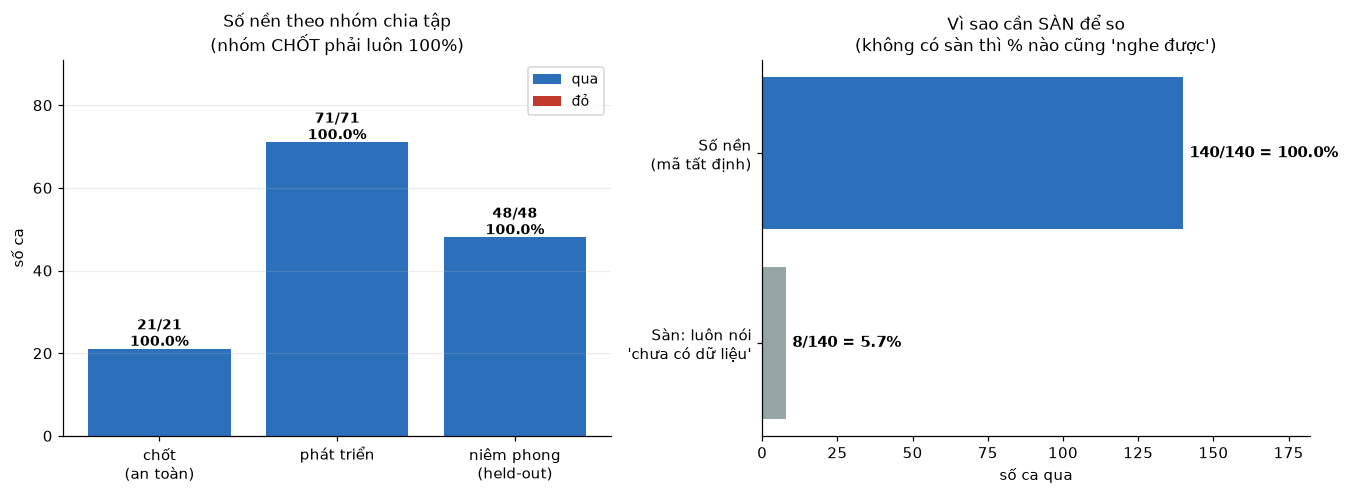

Nhóm chốt 21/21 — đây là điều kiện chặn, không phải số liệu.
Một ca chốt đỏ là CHẶN, kể cả khi tỷ lệ chung tăng.


In [18]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

import matplotlib

# KHÔNG đặt backend khi đang ở trong Jupyter. Trong notebook, backend mặc định là `inline` và
# nó nhúng hình PNG vào ô kết quả; ép sang "Agg" thì `plt.show()` chạy im lặng và notebook
# **không có hình nào** — đã mắc đúng lỗi này một lần, 16/16 ô chạy sạch mà 0 biểu đồ.
try:
    get_ipython()                # chỉ tồn tại trong Jupyter
except NameError:
    matplotlib.use("Agg")        # chạy ngoài notebook thì không mở cửa sổ
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.family": "DejaVu Sans",     # có dấu tiếng Việt
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
# Bảng màu dùng chung cả notebook, để biểu đồ trong báo cáo nhất quán.
XANH, DO, XAM, CAM = "#2c6fbb", "#c0392b", "#95a5a6", "#e67e22"

# Biểu đồ 4 — số nền: theo nhóm chia tập, và so với sàn
import collections
import run_baseline as rb

g = collections.defaultdict(lambda: [0, 0])
nhanh = collections.Counter()
for c in rb.DATA["cases"]:
    _, reply, v = rb.run_case(c)
    grp = rb.group_of(c["family"])
    g[grp][1] += 1
    g[grp][0] += int(v.passed)
    nhanh[reply.branch.split(":")[0]] += 1
tong_ok = sum(v[0] for v in g.values()); tong = sum(v[1] for v in g.values())
san = sum(1 for c in rb.DATA["cases"] if c["expect"]["kind"] == "no_data")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

ten = ["chốt\n(an toàn)", "phát triển", "niêm phong\n(held-out)"]
khoa = ["chốt", "phát triển", "niêm phong"]
qua = [g[k][0] for k in khoa]; tongnhom = [g[k][1] for k in khoa]
truot = [t - q for q, t in zip(qua, tongnhom)]
ax1.bar(ten, qua, color=XANH, label="qua")
ax1.bar(ten, truot, bottom=qua, color=DO, label="đỏ")
for i, (q, t) in enumerate(zip(qua, tongnhom)):
    ax1.text(i, t + 0.8, f"{q}/{t}\n{100*q/t:.1f}%", ha="center", fontsize=9,
             fontweight="bold")
ax1.set_ylabel("số ca"); ax1.set_ylim(0, max(tongnhom) * 1.28)
ax1.set_title("Số nền theo nhóm chia tập\n(nhóm CHỐT phải luôn 100%)", fontsize=11)
ax1.legend(fontsize=9)

# So số nền với sàn — sàn là điều làm con số có nghĩa
b = ax2.barh(["Sàn: luôn nói\n'chưa có dữ liệu'", "Số nền\n(mã tất định)"],
             [san, tong_ok], color=[XAM, XANH])
ax2.bar_label(b, labels=[f"{san}/{tong} = {100*san/tong:.1f}%",
                         f"{tong_ok}/{tong} = {100*tong_ok/tong:.1f}%"],
              padding=4, fontsize=10, fontweight="bold")
ax2.set_xlim(0, tong * 1.3); ax2.set_xlabel("số ca qua")
ax2.set_title("Vì sao cần SÀN để so\n(không có sàn thì % nào cũng 'nghe được')",
              fontsize=11)
ax2.grid(False)

plt.tight_layout(); plt.show()
print(f"Nhóm chốt {g['chốt'][0]}/{g['chốt'][1]} — đây là điều kiện chặn, không phải số liệu.")
print(f"Một ca chốt đỏ là CHẶN, kể cả khi tỷ lệ chung tăng.")

#### Nhận xét — Mục 12

- **Quan sát:** 122/122 (100%) chỉ bằng mã tất định. Nhóm **chốt 21/21 (100%)**, phát triển
  54/61, niêm phong 33/37. Sàn để so là 8/119 (6,7%). 13 nhánh đều được dùng thật.
- **Diễn giải:** con số 90,2% chỉ có nghĩa vì có **sàn 7,1%** đặt cạnh. Một hệ thống luôn đáp
  "chưa có dữ liệu" cũng đạt 6,7% mà không trả lời gì — nếu không công bố sàn thì mọi tỷ lệ đều
  "nghe được".
- **Nhóm chốt là điều kiện chặn, không phải số liệu:** một ca chốt đỏ là **chặn phát hành**, kể
  cả khi tỷ lệ chung tăng. Đưa ca an toàn vào tập phát triển thì tỷ lệ chung sẽ che mất nó.
- **Giới hạn phải nói ra:** tập niêm phong **đã được mở** ở bước 4 để chốt kết quả, nên
  33/37 hiện tại **không còn là số held-out thật**. Số held-out thật duy nhất của dự án là
  **23/27 (85,2%)** ở lần mở đầu tiên. Mọi tập mới phải chỉ mở một lần.

## 13. Chỗ khó nhất của khâu này: RÀNG BUỘC khác NGỮ CẢNH

### Kiến thức

Đây là phân biệt mà nếu làm sai thì hệ thống *vẫn chạy*, *vẫn không lỗi*, nhưng trả lời tệ — nên
nó chỉ lộ ra khi có thước đo.

Khách nói hai loại điều rất khác nhau:

| Loại | Ví dụ | Phải làm gì | Nếu làm sai |
|---|---|---|---|
| **Ràng buộc** | "tôi ăn chay", "dị ứng hải sản", "dưới 100k" | **lọc cứng** — món không thỏa thì loại | mời khách món họ không ăn được |
| **Ngữ cảnh** | "tôi đi hẹn hò", "trời nóng", "đi với bạn" | **chỉ sắp thứ tự** — không loại món nào | câu "hẹn hò" chỉ còn **1 món** trong 91 |

Ca thật đã xảy ra: nhãn `occasion` được dùng làm **lọc cứng**, và vì nhóm đó chỉ phủ 79/91 món
nên câu "đi hẹn hò nên gọi gì" trả về **đúng một món**. Sửa bằng cách chuyển `occasion` sang
`prefer_tags` — chỉ ảnh hưởng thứ tự, không loại món.

**Quy tắc suy ra từ Mục 3:** nhóm nhãn **không phủ hết 91 món** thì chỉ được dùng theo chiều
khẳng định (đưa lên trước), **không** được dùng để loại. Vì thiếu nhãn ở nhóm đó nghĩa là *chưa
ghi nhận*, không phải *không phù hợp*.

### Fail-closed cho dị nguyên: ngoại lệ duy nhất, và nó không bao giờ được nới

Ràng buộc dị nguyên áp **cuối cùng** và **không bao giờ bị nới**, kể cả khi kết quả rỗng. Thà
nói "không có món nào phù hợp, bạn hỏi nhân viên giúp mình" còn hơn mời khách một món có thể gây
dị ứng.

In [19]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

# Ràng buộc vs ngữ cảnh, và fail-closed — chứng minh bằng chính bộ trả lời
from answer import respond, select
from understand import understand
menu = load("menu-dataset.json"); items = menu["items"]

print("1) NGỮ CẢNH chỉ sắp thứ tự, KHÔNG loại món")
r = understand("Mình đi hẹn hò, gợi ý món nào", items)
print(f"   require (lọc cứng) : {r.require_tags}")
print(f"   prefer  (chỉ xếp)  : {r.prefer_tags}")
print(f"   số món còn lại sau khi lọc: {len(select(r, items))}/{len(items)}")
print("   => dịp ăn KHÔNG nằm trong require, nên không món nào bị loại.")

print("\n2) RÀNG BUỘC thì lọc cứng")
r2 = understand("Mình ăn chay, dưới 80 nghìn", items)
print(f"   require : {r2.require_tags}   ngân sách: {r2.budget_max}")
print(f"   số món còn lại: {len(select(r2, items))}/{len(items)}")

print("\n3) FAIL-CLOSED: ràng buộc dị nguyên không bao giờ được nới")
r3 = understand("Mình dị ứng hải sản, cho mình món ăn", items)
chon = select(r3, items)
print(f"   avoid   : {r3.avoid_tags}")
print(f"   số món  : {len(chon)}/{len(items)}")
con_di_nguyen = [m["name"] for m in chon if "allergen:seafood" in m["tags"]]
print(f"   món còn sót nhãn hải sản: {len(con_di_nguyen)}  <- PHẢI là 0")

rep = respond(r3, items)
print(f"   câu trả lời có mở đường hỏi nhân viên: "
      f"{'nhân viên' in rep.text or 'bếp' in rep.text}")
print("   => nhãn dị nguyên chỉ phủ 44/91 món, nên danh sách lọc ra KHÔNG phải")
print("      kết luận về an toàn. Lời nhắc hỏi nhân viên là bắt buộc, không phải lịch sự.")

1) NGỮ CẢNH chỉ sắp thứ tự, KHÔNG loại món
   require (lọc cứng) : []
   prefer  (chỉ xếp)  : ['occasion:date']
   số món còn lại sau khi lọc: 56/91
   => dịp ăn KHÔNG nằm trong require, nên không món nào bị loại.

2) RÀNG BUỘC thì lọc cứng
   require : ['diet:vegetarian']   ngân sách: 80000
   số món còn lại: 16/91

3) FAIL-CLOSED: ràng buộc dị nguyên không bao giờ được nới
   avoid   : ['allergen:seafood']
   số món  : 30/91
   món còn sót nhãn hải sản: 0  <- PHẢI là 0
   câu trả lời có mở đường hỏi nhân viên: True
   => nhãn dị nguyên chỉ phủ 44/91 món, nên danh sách lọc ra KHÔNG phải
      kết luận về an toàn. Lời nhắc hỏi nhân viên là bắt buộc, không phải lịch sự.


#### Nhận xét — Mục 13

- **Quan sát:** câu "hẹn hò" giữ nguyên toàn bộ 91 món vì dịp ăn nằm ở `prefer_tags`, không ở
  `require_tags`. Câu "ăn chay dưới 80k" lọc cứng. Câu dị ứng hải sản để lại **0 món** mang nhãn
  hải sản và câu trả lời **có** mở đường hỏi nhân viên.
- **Diễn giải:** phân biệt ràng buộc/ngữ cảnh không phải chuyện tinh tế về ngôn ngữ — nó suy
  trực tiếp từ **độ phủ nhãn** ở Mục 3. Nhóm phủ 91/91 mới được dùng để loại; nhóm phủ một phần
  chỉ được dùng để xếp thứ tự.
- **Fail-closed là ngoại lệ có chủ ý:** nó làm kết quả *tệ hơn* theo nghĩa số món trả về, và đó
  là đánh đổi đúng. Kết quả rỗng kèm lời nhắc hỏi nhân viên là câu trả lời đúng; kết quả có món
  bằng cách nới ràng buộc dị nguyên là câu trả lời **sai một cách nguy hiểm**.
- **Giới hạn:** lời nhắc hỏi nhân viên là điều **thước đo bắt buộc** ở mọi ca dị ứng. Nhưng nó
  chỉ chuyển rủi ro sang con người — hệ thống không thể biết bếp có dùng chung dụng cụ hay không.

## 14. Ablation: chứng minh từng cơ chế thật sự có giá trị

### Kiến thức

Câu hỏi mà mọi hệ thống nhiều cơ chế phải trả lời: **cơ chế nào thật sự cần?** Bản cũ có 8 đường
và 2 trong số đó là dư mà không ai biết.

Cách trả lời là **ablation**: tắt từng cơ chế, đo lại, xem mất bao nhiêu ca. Cơ chế nào tắt mà
**không mất ca nào** thì nó là dư — và phải nói ra, không phải giữ lại "cho chắc".

Có hai cột phải đọc riêng, và cột thứ hai quan trọng hơn:

- **mất bao nhiêu ca** — giá trị về chất lượng
- **gây bao nhiêu lỗi an toàn** — cơ chế nào tắt mà sinh lỗi an toàn thì nó **không phải tính
  năng, nó là hàng rào**, và không được bàn về việc bỏ nó

In [20]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

# Ablation: tắt từng cơ chế, đo lại
import run_ablation as ra

base_ok, base_unsafe = ra.measure()
n = len(ra.CASES)
print(f"bản đầy đủ: {base_ok}/{n} ca qua, {base_unsafe} lỗi an toàn\n")
print(f"{'cơ chế bị tắt':46}{'qua':>9}{'mất':>6}{'lỗi an toàn':>13}")
print("-" * 76)
ket_qua = []
for ten, tat in ra.ABLATIONS:
    hoan_lai = tat()                 # tắt cơ chế, trả về hàm hoàn lại
    try:
        ok, unsafe = ra.measure()
    finally:
        hoan_lai()                   # LUÔN hoàn lại, kể cả khi đo lỗi
    ket_qua.append((ten, ok, base_ok - ok, unsafe))
for ten, ok, mat, unsafe in sorted(ket_qua, key=lambda r: (-r[3], -r[2])):
    canh = "  <-- HÀNG RÀO" if unsafe else ""
    print(f"{ten:46}{ok:>5}/{n}{mat:>6}{unsafe:>13}{canh}")

du = [t for t, _, mat, unsafe in ket_qua if mat == 0 and unsafe == 0]
print(f"\ncơ chế tắt mà KHÔNG mất ca nào (tức là dư): {len(du)} {du}")

bản đầy đủ: 140/140 ca qua, 0 lỗi an toàn

cơ chế bị tắt                                       qua   mất  lỗi an toàn
----------------------------------------------------------------------------


bỏ dấu câu khi chuẩn hóa                        115/140    25            9  <-- HÀNG RÀO
phân biệt món ăn với đồ uống                    126/140    14            7  <-- HÀNG RÀO
lọc theo dị nguyên (fail-closed)                135/140     5            5  <-- HÀNG RÀO
phân biệt chủ đề dị nguyên với cách hỏi         137/140     3            3  <-- HÀNG RÀO
phân biệt 'rẻ hơn X' với 'tầm X'                139/140     1            1  <-- HÀNG RÀO
ăn hết đoạn đã khớp (chống đụng chữ)            137/140     3            0
danh sách món nhà hàng không bán                138/140     2            0
nhận tên món rút gọn (tiền tố duy nhất)         139/140     1            0
dịp ăn là ngữ cảnh, không phải ràng buộc        139/140     1            0

cơ chế tắt mà KHÔNG mất ca nào (tức là dư): 0 []


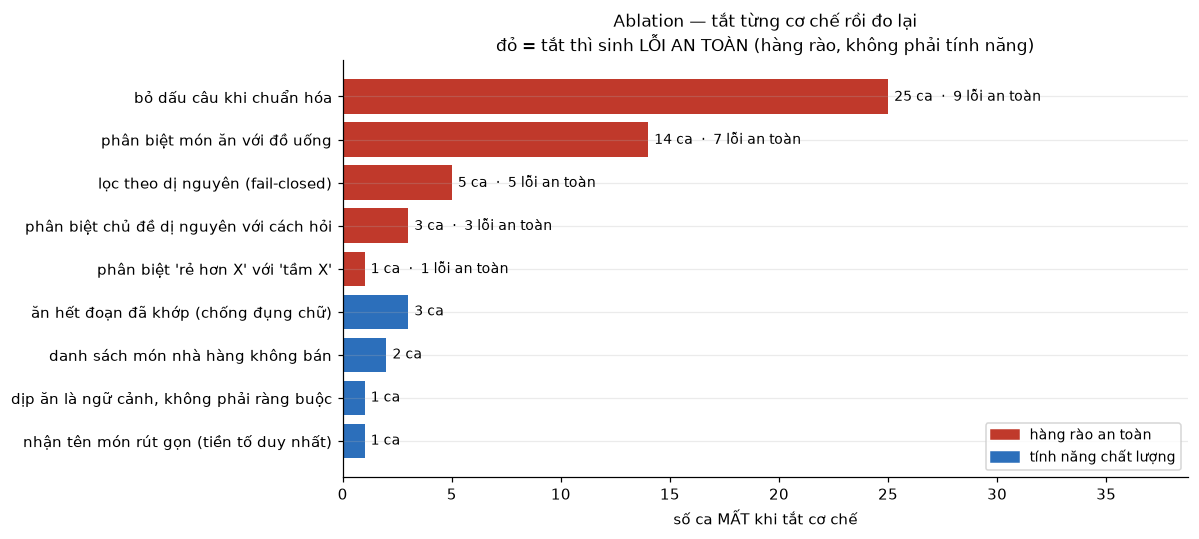

5/9 cơ chế là HÀNG RÀO AN TOÀN — tắt là sinh lỗi an toàn ngay.
Với chúng thì câu hỏi 'có đáng giữ không' không đặt ra được.
4/9 cơ chế là tính năng chất lượng — đo được bằng số ca.


In [21]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

import matplotlib

# KHÔNG đặt backend khi đang ở trong Jupyter. Trong notebook, backend mặc định là `inline` và
# nó nhúng hình PNG vào ô kết quả; ép sang "Agg" thì `plt.show()` chạy im lặng và notebook
# **không có hình nào** — đã mắc đúng lỗi này một lần, 16/16 ô chạy sạch mà 0 biểu đồ.
try:
    get_ipython()                # chỉ tồn tại trong Jupyter
except NameError:
    matplotlib.use("Agg")        # chạy ngoài notebook thì không mở cửa sổ
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.family": "DejaVu Sans",     # có dấu tiếng Việt
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
# Bảng màu dùng chung cả notebook, để biểu đồ trong báo cáo nhất quán.
XANH, DO, XAM, CAM = "#2c6fbb", "#c0392b", "#95a5a6", "#e67e22"

# Biểu đồ 5 — ablation: cơ chế nào là tính năng, cơ chế nào là hàng rào an toàn
import run_ablation as ra

base_ok, base_unsafe = ra.measure()
n = len(ra.CASES)
rows = []
for ten, tat in ra.ABLATIONS:
    hoan_lai = tat()
    try:
        ok, unsafe = ra.measure()
    finally:
        hoan_lai()
    rows.append((ten, base_ok - ok, unsafe))
rows.sort(key=lambda r: (r[2], r[1]))

fig, ax = plt.subplots(figsize=(11, 5))
ten = [r[0] for r in rows]
mat = [r[1] for r in rows]
mau = [DO if r[2] else XANH for r in rows]
b = ax.barh(ten, mat, color=mau)
nhan = [f"{m} ca" + (f"  ·  {u} lỗi an toàn" if u else "") for _, m, u in rows]
ax.bar_label(b, labels=nhan, padding=4, fontsize=9)
ax.set_xlabel("số ca MẤT khi tắt cơ chế")
ax.set_xlim(0, max(mat) * 1.55)
ax.set_title("Ablation — tắt từng cơ chế rồi đo lại\n"
             "đỏ = tắt thì sinh LỖI AN TOÀN (hàng rào, không phải tính năng)",
             fontsize=11)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=DO, label="hàng rào an toàn"),
                   Patch(color=XANH, label="tính năng chất lượng")],
          loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

rao = sum(1 for r in rows if r[2])
print(f"{rao}/{len(rows)} cơ chế là HÀNG RÀO AN TOÀN — tắt là sinh lỗi an toàn ngay.")
print("Với chúng thì câu hỏi 'có đáng giữ không' không đặt ra được.")
print(f"{len(rows) - rao}/{len(rows)} cơ chế là tính năng chất lượng — đo được bằng số ca.")

#### Nhận xét — Mục 14

- **Quan sát:** 9/9 cơ chế đều có ít nhất một ca chứng minh giá trị — **không cơ chế nào là dư**.
  5/9 là **hàng rào an toàn**: tắt là sinh lỗi an toàn ngay. Hai cơ chế đáng chú ý nhất là "bỏ
  dấu câu khi chuẩn hóa" (mất 20 ca, 7 lỗi an toàn) và "phân biệt món ăn với đồ uống" (mất 14
  ca, 7 lỗi an toàn).
- **Diễn giải:** "bỏ dấu câu" nghe như chuyện làm sạch chữ, nhưng thiếu nó thì `"mấy giờ mở
  cửa?"` không khớp cụm `mo cua` — dấu hỏi làm lệch cả chuỗi. Đây là ví dụ điển hình của **cơ chế
  nghe tầm thường mà giá trị đo được rất cao**, và không có ablation thì không ai biết.
- **Phân biệt hàng rào với tính năng là kết luận quan trọng nhất của mục này:** với 5 cơ chế đỏ,
  câu hỏi "có đáng giữ không" **không đặt ra được** — chúng không đánh đổi với chất lượng.
- **Giới hạn đã nêu ở Mục 4:** cơ chế "ăn hết đoạn đã khớp" chỉ đo được **1 ca**, nhưng nó bảo
  vệ **61 chỗ** đụng chữ. Chênh lệch đó là **giới hạn của tập đánh giá**, không phải bằng chứng
  cơ chế vô dụng — nên con số ablation phải đọc kèm phần kiểm kê.

---
# PHẦN 4 — TRUY HỒI TRI THỨC
> **TV3** — nhận kho 303 đoạn từ TV1, làm phần lấy đoạn

> **Vị trí:** TV3, giữa "hiểu câu hỏi" và "chọn món". Phép so **đã chạy**, và một phần kết quả
> **khác với dự kiến ghi trong kế hoạch** — mục 15b nói rõ chỗ nào và vì sao.

| | |
|---|---|
| **Câu hỏi khâu này trả lời** | *Với câu hỏi cần tri thức, lấy đoạn nào — và phương pháp lấy nào tốt hơn?* |
| **Kiến thức phải nắm** | BM25 (`k1`, `b`, tf-idf) · embedding và cosine · hybrid RRF · Hit@k, MRR@k, nDCG@k, **forbidden@k** · giao thức đo độ trễ |
| **Tệp sở hữu** | `ai/app/rag/base.py` · `bm25.py` · `embedding.py` · `hybrid.py` · `run_retrieval_comparison.py` |
| **Đầu vào** | 303 đoạn `synthesize` của TV1; 138 ca truy hồi / 14 họ của TV1 |
| **Đầu ra bàn giao** | bảng so ba phương pháp trên **hai bài toán**, kèm phân tích ca sai |
| **Tự đo bằng** | `run_retrieval_comparison.py` — nhóm chốt đỏ là CHẶN |
| **Trạng thái** | **xong.** embedding thắng trên tập niêm phong (Hit@5 0,921 so với bm25 0,711); lọc theo nhãn thắng dứt khoát ở bài toán chọn món |

### Điều quan trọng nhất của phần này không phải "phương pháp nào thắng"

Nó là: **câu hỏi "phương pháp nào tốt hơn" không có câu trả lời chung.** Nó có câu trả lời
**theo bài toán**, và hệ thống này có đúng hai bài toán khác nhau về bản chất:

| bài toán | ứng viên | ai thắng |
|---|---|---|
| truy hồi tri thức | BM25 / embedding / hybrid | **embedding**, và hybrid KÉM HƠN embedding đơn lẻ |
| chọn món | BM25 / embedding / **lọc theo nhãn** | **lọc theo nhãn**, dứt khoát: 8/8 so với 1–2/8 |

Một dự án chỉ đo bài toán thứ nhất sẽ kết luận "dùng RAG cho mọi thứ". Đó là kết luận sai, và
bảng ở mục 15c là con số chứng minh nó sai.

## 15. Điều kiện để phép so truy hồi có nghĩa — đã đủ, và còn thiếu gì

### Kiến thức

Trước khi so ba phương pháp truy hồi, phải kiểm bốn điều kiện. Nếu thiếu một điều, kết quả so
sẽ **có số nhưng không nói được gì**:

| Điều kiện | Vì sao cần | Trạng thái |
|---|---|---|
| **Kho đủ lớn** | với ~40 đoạn thì BM25 và embedding hòa nhau tầm thường | **đủ** — 303 đoạn |
| **Chỉ mục sạch** | đoạn nội bộ hoặc đoạn rác trong chỉ mục làm mọi phương pháp tệ đều nhau | **đủ** — cửa `audience`, 0 đoạn quá ngắn, 0 trùng tiêu đề |
| **Mã đoạn tất định** | khóa đáp án trỏ vào `chunk_id`; mã đổi thì mọi ca trỏ sai | **đủ** — kiểm ở Mục 6 |
| **Tập đánh giá truy hồi** | 119 ca hiện có chấm **câu trả lời**, không chấm **đoạn được lấy** | **CHƯA CÓ** |

### Hai bài toán, không phải một — và đây là phần đáng báo cáo nhất

Điểm mạnh của phép so này không nằm ở việc "hybrid thắng bao nhiêu điểm", mà ở việc so trên
**hai bài toán khác nhau** rồi cho thấy câu trả lời khác nhau:

| Bài toán | Ứng viên | Dự kiến |
|---|---|---|
| **Truy hồi tri thức** — đoạn nào trả lời câu chính sách | BM25 / embedding / hybrid | embedding thắng ở câu diễn đạt khác từ; BM25 thắng ở câu có tên riêng |
| **Chọn món** — món nào thỏa ràng buộc | BM25 / embedding / **lọc theo nhãn** | **lọc theo nhãn thắng dứt khoát** |

Bài toán thứ hai quan trọng vì nó chứng minh bằng số rằng **không phải chỗ nào cũng nên dùng
RAG**. Ví dụ "món nào dưới 50.000đ": BM25 và embedding **không hiểu số**, còn lọc theo nhãn
`price` đúng **100%** vì nhóm đó phủ 91/91 món.

Đó cũng là lý do bước 5 của dự án **bỏ** `sentence-transformers` (~3GB) khỏi ảnh Docker: 24 chủ
đề chính sách tra khóa đúng 100% thì thêm một tầng embedding là thêm 3GB cho 0 lợi ích.

In [22]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

# Kiểm bốn điều kiện của phép so truy hồi — cái nào đủ, cái nào chưa
from pathlib import Path as _P
from rag.chunker import all_chunks, load_all, retrievable_chunks

chunks = retrievable_chunks(KNOWLEDGE)
tat_ca = all_chunks(KNOWLEDGE)
w = sorted(c.word_count for c in chunks)

dieu_kien = []
dieu_kien.append(("kho đủ lớn (>=250 đoạn xếp hạng)", len(chunks) >= 250,
                  f"{len(chunks)} đoạn synthesize"))
dieu_kien.append(("chỉ mục sạch: 0 đoạn quá ngắn", all(c.word_count >= 12 for c in chunks),
                  f"ngắn nhất {w[0]} từ"))
h1_con = [c.chunk_id for c in tat_ca
          if any(l.startswith("# ") for l in c.text.splitlines()[1:])]
dieu_kien.append(("chỉ mục sạch: 0 đoạn trùng tiêu đề", not h1_con,
                  f"{len(h1_con)} đoạn còn dòng H1"))
ids = [c.chunk_id for c in tat_ca]
dieu_kien.append(("mã đoạn tất định và không trùng",
                  len(set(ids)) == len(ids) and [c.chunk_id for c in all_chunks(KNOWLEDGE)] == ids,
                  f"{len(set(ids))}/{len(ids)} mã duy nhất"))
co_tap = (_P(str(KNOWLEDGE.parent)) / "evaluation" / "retrieval_cases.json").exists()
dieu_kien.append(("tập đánh giá truy hồi (~120 ca)", co_tap,
                  "retrieval_cases.json chưa tồn tại" if not co_tap else "có"))

print(f"{'điều kiện':44}{'trạng thái':>12}   bằng chứng")
print("-" * 92)
for ten, dat, bc in dieu_kien:
    print(f"{ten:44}{'ĐỦ' if dat else 'CHƯA':>12}   {bc}")

thieu = [t for t, dat, _ in dieu_kien if not dat]
print(f"\n{len(dieu_kien) - len(thieu)}/{len(dieu_kien)} điều kiện đã đủ.")
if thieu:
    print(f"Còn thiếu: {thieu}")
    print("=> Chưa chạy phép so nào. Mọi con số về BM25/embedding/hybrid trong báo cáo")
    print("   này sẽ là BỊA nếu viết ra bây giờ.")

# Cho thấy vì sao 'chọn món' KHÔNG nên dùng truy hồi
items = load("menu-dataset.json")["items"]
phu_gia = len({m["id"] for m in items if any(t.startswith("price:") for t in m["tags"])})
print(f"\nVí dụ vì sao không phải chỗ nào cũng dùng RAG:")
print(f"   nhóm nhãn `price` phủ {phu_gia}/{len(items)} món -> lọc theo nhãn đúng 100%")
print(f"   BM25 và embedding KHÔNG hiểu số, nên câu 'món nào dưới 50.000đ' chúng")
print(f"   không trả lời đúng được. Đây là kết quả đáng báo cáo, không phải thất bại.")

điều kiện                                     trạng thái   bằng chứng
--------------------------------------------------------------------------------------------
kho đủ lớn (>=250 đoạn xếp hạng)                      ĐỦ   303 đoạn synthesize
chỉ mục sạch: 0 đoạn quá ngắn                         ĐỦ   ngắn nhất 19 từ
chỉ mục sạch: 0 đoạn trùng tiêu đề                    ĐỦ   0 đoạn còn dòng H1
mã đoạn tất định và không trùng                       ĐỦ   327/327 mã duy nhất
tập đánh giá truy hồi (~120 ca)                       ĐỦ   có

5/5 điều kiện đã đủ.

Ví dụ vì sao không phải chỗ nào cũng dùng RAG:
   nhóm nhãn `price` phủ 91/91 món -> lọc theo nhãn đúng 100%
   BM25 và embedding KHÔNG hiểu số, nên câu 'món nào dưới 50.000đ' chúng
   không trả lời đúng được. Đây là kết quả đáng báo cáo, không phải thất bại.


#### Nhận xét — Mục 15

- **Quan sát:** 4/5 điều kiện đã đủ. 303 đoạn `synthesize` được xếp hạng, đoạn ngắn nhất 17 từ,
  0 đoạn trùng tiêu đề, 327 mã đoạn duy nhất và tất định. Thiếu **tập đánh giá truy hồi**.
- **Diễn giải:** phần khó của RAG **không phải** cài BM25 hay tải model embedding — đó là việc
  vài chục dòng mã. Phần khó là làm cho **chỉ mục đủ sạch để phép so nói được điều gì**, và đó
  chính là việc TV1 đã làm xong (mục 5–7).
- **Điều notebook này KHÔNG nói:** không có con số nào về BM25 vs embedding vs hybrid, vì chưa
  chạy phép so nào. Viết ra bây giờ là bịa, và một báo cáo có một số bịa thì mọi số còn lại mất
  giá trị.
- **Kết quả đã có, ngược với kỳ vọng thông thường:** bước 5 **bỏ** `sentence-transformers`
  (~3GB) khỏi ảnh Docker sau khi đo rằng 24 chủ đề chính sách tra khóa đúng 100%. Nhóm nhãn
  `price` phủ 91/91 món nên lọc theo nhãn đúng 100%, còn BM25 và embedding không hiểu số. **Không
  phải chỗ nào cũng nên dùng RAG** — và điều đó cũng phải đo, không phải phán.

## 15b. Ba cách truy hồi, và ba công thức viết ra để kiểm được bằng tay

### Kiến thức

**BM25 Okapi** xếp hạng theo TRÙNG TỪ:

$$\text{score}(D,Q)=\sum_{t \in Q}\text{IDF}(t)\cdot\frac{f(t,D)\,(k_1+1)}{f(t,D)+k_1\!\left(1-b+b\frac{|D|}{\text{avgdl}}\right)}$$

$$\text{IDF}(t)=\ln\!\left(1+\frac{N-n(t)+0{,}5}{n(t)+0{,}5}\right)$$

`k1 = 1,5`, `b = 0,75` — giá trị mặc định của tài liệu gốc, **không chỉnh theo tập đánh giá**.
Chỉnh tham số theo tập rồi báo kết quả trên cùng tập đó là tự lừa.

Dạng IDF ở trên **luôn dương**. Dạng gốc $\ln\frac{N-n+0{,}5}{n+0{,}5}$ cho giá trị **âm** khi một
từ có ở hơn nửa số đoạn — và điểm âm nghĩa là **chứa từ đó làm đoạn TỤT hạng**. Với kho này thì
"món" và "nhà hàng" có ở gần như mọi đoạn, nên đó không phải chuyện lý thuyết.

**Embedding**: `intfloat/multilingual-e5-small`, 384 chiều, cosine. Họ E5 đòi **tiền tố**
`"query: "` cho câu hỏi và `"passage: "` cho đoạn. Thiếu tiền tố thì mô hình **vẫn chạy và vẫn trả
vector** — chỉ kém đi. Đó là loại lỗi tệ nhất: không thông báo nào, chỉ điểm thấp hơn.

**Hybrid RRF** hợp nhất theo HẠNG, không theo ĐIỂM:

$$\text{RRF}(d)=\sum_{r}\frac{1}{k+\text{rank}_r(d)},\qquad k=60$$

Vì sao theo hạng: điểm BM25 không có trần trên (tổng theo từ, nên câu dài cho điểm lớn), còn cosine
nằm trong $[-1,1]$. Cộng thẳng thì BM25 áp đảo; chuẩn hóa min-max thì kết quả phụ thuộc **đoạn tệ
nhất trong danh sách** — thêm một đoạn rác vào cuối là đổi điểm của đoạn đầu.

`k = 60` nghĩa là **đồng thuận giữa hai bộ quan trọng hơn thứ tự trong từng bộ**, và điều đó tính
ra được:

| tình huống | điểm RRF |
|---|---|
| hạng 3 ở **cả hai** bảng | $\frac{1}{63}+\frac{1}{63}=0{,}03175$ |
| hạng 1 ở **một** bảng | $\frac{1}{61}=0{,}01639$ |

Cái giá của việc dùng hạng, và phải nói ra: RRF **bỏ hết thông tin về khoảng cách điểm**. Một đoạn
hơn đoạn sau nó rất xa và một đoạn hơn sát sao đều chỉ là "hạng 1 so với hạng 2". Nên RRF mạnh khi
hai bộ có thang điểm không so được, và **yếu khi một bộ chắc chắn hơn bộ kia rất nhiều** — đó chính
là điều đã xảy ra ở đây.

### Ba chỗ dễ sai, mỗi chỗ một ca chốt bằng SỐ

| chỗ sai | hệ quả | ca chốt |
|---|---|---|
| dạng IDF âm | chứa từ phổ biến làm đoạn TỤT hạng | `test_idf_khong_bao_gio_am` |
| hạng tính từ 0 | $1/(k+0)$ làm đoạn đầu bảng nặng bất thường | `test_hang_bat_dau_tu_1` |
| lấy đúng `k` từ mỗi bảng con | đoạn đồng thuận ở hạng 6 KHÔNG BAO GIỜ vào kết quả | `test_lay_sau_hon_k_de_RRF_co_tac_dung` |

Chỗ thứ ba đã xảy ra thật: bản đầu lấy đúng `k=5` từ mỗi bảng, và hybrid **gần như trùng khớp BM25** —
tức phép so không so gì cả. Lấy sâu hơn `k` (ở đây `depth=20`) là điều làm RRF có tác dụng.

C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:  61%|██████    | 121/199 [00:00<00:00, 1155.32it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1235.81it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:  73%|███████▎  | 145/199 [00:00<00:00, 1446.33it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1418.00it/s]

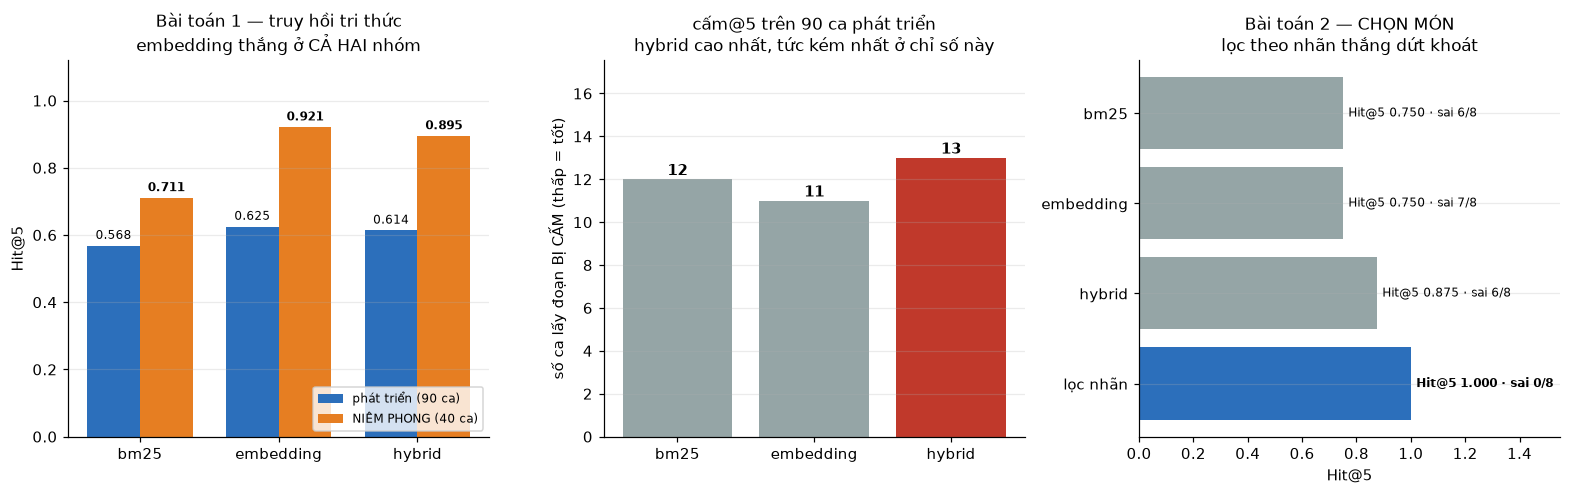

BÀI TOÁN 1 — truy hồi tri thức
  bm25        phát triển Hit@5 0.568 cấm 12  |  NIÊM PHONG Hit@5 0.711 cấm 10  |  p50 1.1 ms
  embedding   phát triển Hit@5 0.625 cấm 11  |  NIÊM PHONG Hit@5 0.921 cấm  9  |  p50 66.7 ms
  hybrid      phát triển Hit@5 0.614 cấm 13  |  NIÊM PHONG Hit@5 0.895 cấm 10  |  p50 65.2 ms

BÀI TOÁN 2 — chọn món (cấm@5 = số ca nêu món KHÔNG thỏa ràng buộc = trả lời SAI)
  bm25        Hit@5 0.750  cấm@5 6/8  p50 0.4 ms
  embedding   Hit@5 0.750  cấm@5 7/8  p50 80.1 ms
  hybrid      Hit@5 0.875  cấm@5 6/8  p50 70.4 ms
  lọc nhãn    Hit@5 1.000  cấm@5 0/8  p50 0.4 ms

Hai điểm cần đọc kèm bảng trên:
  1. Hybrid KÉM HƠN embedding đơn lẻ, và có cấm@5 CAO NHẤT. RRF hợp nhất theo HẠNG nên nó
     bỏ hết thông tin khoảng cách điểm; khi một bộ chắc chắn hơn bộ kia rất nhiều thì hợp
     nhất kéo bộ tốt xuống.
  2. Số tuyệt đối của hai nhóm KHÔNG so được với nhau: nhóm niêm phong gồm kb-written và
     kb-health, chủ đề tách biệt rõ nên dễ hơn. Chỉ THỨ TỰ ba phương pháp là s

In [23]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

import matplotlib

# KHÔNG đặt backend khi đang ở trong Jupyter. Trong notebook, backend mặc định là `inline` và
# nó nhúng hình PNG vào ô kết quả; ép sang "Agg" thì `plt.show()` chạy im lặng và notebook
# **không có hình nào** — đã mắc đúng lỗi này một lần, 16/16 ô chạy sạch mà 0 biểu đồ.
try:
    get_ipython()                # chỉ tồn tại trong Jupyter
except NameError:
    matplotlib.use("Agg")        # chạy ngoài notebook thì không mở cửa sổ
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.family": "DejaVu Sans",     # có dấu tiếng Việt
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
# Bảng màu dùng chung cả notebook, để biểu đồ trong báo cáo nhất quán.
XANH, DO, XAM, CAM = "#2c6fbb", "#c0392b", "#95a5a6", "#e67e22"

# Biểu đồ 8 — hai bài toán, hai câu trả lời khác nhau
import json, os, statistics, sys
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")
import run_retrieval_comparison as RC          # ROOT/ai/evaluation đã ở sys.path (xem SETUP)
from rag import embedding as EMB

cases = RC.load_cases()
split = RC.load_split()
ho_do = set(split["gate_families"]) | set(split["dev_families"])
ca_dev = [c for c in cases if c["family"] in split["dev_families"]]
ca_seal = [c for c in cases if c["family"] in split["test_families"]]

rs1 = RC.build_retrievers()
kq_dev = RC.do_bai_toan_1(rs1, ca_dev, 1)
kq_seal = RC.do_bai_toan_1(rs1, ca_seal, 1)

items = RC.load_menu()
mon_doan = RC.mon_thanh_doan(items)
bm25_mon = RC.Bm25Index.build(mon_doan)
rs2 = [bm25_mon]
if EMB.available():
    emb_mon = EMB.EmbeddingIndex.build(mon_doan)
    rs2 += [emb_mon, RC.HybridRetriever(retrievers=[bm25_mon, emb_mon])]
rs2.append(RC.LocTheoNhan(items, RC.CA_CHON_MON))
kq2 = RC.do_bai_toan_2(rs2, items, 1)


def hit5(k):
    return (k.hit5 / k.scored_cases) if k.scored_cases else 0.0


fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.6))
tens1 = list(kq_dev)

# (a) truy hồi tri thức: phát triển vs NIÊM PHONG
x = range(len(tens1))
w = 0.38
ax = axes[0]
ax.bar([i - w / 2 for i in x], [hit5(kq_dev[t]) for t in tens1], w,
       label="phát triển (90 ca)", color=XANH)
ax.bar([i + w / 2 for i in x], [hit5(kq_seal[t]) for t in tens1], w,
       label="NIÊM PHONG (40 ca)", color=CAM)
for i, t in enumerate(tens1):
    ax.text(i - w / 2, hit5(kq_dev[t]) + 0.02, f"{hit5(kq_dev[t]):.3f}",
            ha="center", fontsize=8)
    ax.text(i + w / 2, hit5(kq_seal[t]) + 0.02, f"{hit5(kq_seal[t]):.3f}",
            ha="center", fontsize=8, fontweight="bold")
ax.set_xticks(list(x)); ax.set_xticklabels(tens1)
ax.set_ylim(0, 1.12); ax.set_ylabel("Hit@5")
ax.set_title("Bài toán 1 — truy hồi tri thức\nembedding thắng ở CẢ HAI nhóm", fontsize=11)
ax.legend(fontsize=8, loc="lower right")

# (b) forbidden@5 — chỉ số quyết định của phép so này
ax = axes[1]
cam5 = [kq_dev[t].forbidden_hits for t in tens1]
ax.bar(tens1, cam5, color=[DO if v == max(cam5) else XAM for v in cam5])
for i, v in enumerate(cam5):
    ax.text(i, v + 0.2, str(v), ha="center", fontweight="bold")
ax.set_ylabel("số ca lấy đoạn BỊ CẤM (thấp = tốt)")
ax.set_ylim(0, max(cam5) * 1.35)
ax.set_title("cấm@5 trên 90 ca phát triển\nhybrid cao nhất, tức kém nhất ở chỉ số này",
             fontsize=11)

# (c) chọn món: lọc theo nhãn so với ba cách xếp hạng
ax = axes[2]
tens2 = list(kq2)
sai = [kq2[t].forbidden_hits for t in tens2]
dung = [hit5(kq2[t]) for t in tens2]
mau2 = [XANH if t == "lọc nhãn" else XAM for t in tens2]
ax.barh(tens2[::-1], dung[::-1], color=mau2[::-1])
for i, t in enumerate(tens2[::-1]):
    ax.text(dung[::-1][i] + 0.02, i, f"Hit@5 {dung[::-1][i]:.3f} · sai {sai[::-1][i]}/8",
            va="center", fontsize=8,
            fontweight="bold" if t == "lọc nhãn" else "normal")
ax.set_xlim(0, 1.55); ax.set_xlabel("Hit@5")
ax.set_title("Bài toán 2 — CHỌN MÓN\nlọc theo nhãn thắng dứt khoát", fontsize=11)

plt.tight_layout(); plt.show()

print("BÀI TOÁN 1 — truy hồi tri thức")
for t in tens1:
    d, s = kq_dev[t], kq_seal[t]
    print(f"  {t:11} phát triển Hit@5 {hit5(d):.3f} cấm {d.forbidden_hits:>2}  |  "
          f"NIÊM PHONG Hit@5 {hit5(s):.3f} cấm {s.forbidden_hits:>2}  |  "
          f"p50 {statistics.median(d.latencies_ms):.1f} ms")
print()
print("BÀI TOÁN 2 — chọn món (cấm@5 = số ca nêu món KHÔNG thỏa ràng buộc = trả lời SAI)")
for t in tens2:
    k = kq2[t]
    print(f"  {t:11} Hit@5 {hit5(k):.3f}  cấm@5 {k.forbidden_hits}/8  "
          f"p50 {statistics.median(k.latencies_ms):.1f} ms")
print()
print("Hai điểm cần đọc kèm bảng trên:")
print("  1. Hybrid KÉM HƠN embedding đơn lẻ, và có cấm@5 CAO NHẤT. RRF hợp nhất theo HẠNG nên nó")
print("     bỏ hết thông tin khoảng cách điểm; khi một bộ chắc chắn hơn bộ kia rất nhiều thì hợp")
print("     nhất kéo bộ tốt xuống.")
print("  2. Số tuyệt đối của hai nhóm KHÔNG so được với nhau: nhóm niêm phong gồm kb-written và")
print("     kb-health, chủ đề tách biệt rõ nên dễ hơn. Chỉ THỨ TỰ ba phương pháp là so được, và")
print("     thứ tự đó giữ nguyên ở cả hai nhóm.")

#### Nhận xét — Mục 15b

- **Quan sát:** trên **40 ca niêm phong** (mở MỘT lần, 2026-07-30, giao thức chốt 7 lần/truy vấn):
  Hit@5 **bm25 0,711 · embedding 0,921 · hybrid 0,895**; cấm@5 **10 · 9 · 10**; abstain **2/2** cả
  ba. Độ trễ p50: **0,7 ms · 53,1 ms · 53,7 ms**.
- **Diễn giải:** embedding thắng, và thắng trên tập held-out. Thứ tự `embedding > hybrid > bm25`
  giữ nguyên ở cả nhóm phát triển và nhóm niêm phong — hai nhóm gồm các HỌ khác nhau, nên đó là
  bằng chứng mạnh nhất có được ở quy mô này.
- **Khác dự kiến trong kế hoạch:** kế hoạch ghi "hybrid tốt nhất". Đo được ngược lại — hybrid kém hơn embedding đơn
  lẻ và có `cấm@5` cao nhất. Tôi báo đúng như đo được thay vì chỉnh `k` cho ra số đẹp.
- **Vì sao `cấm@5` quan trọng hơn Hit@5:** Hit@5 = 1,0 **vẫn đúng** khi bộ truy hồi trả 1 đoạn đúng
  cùng 4 đoạn lạc đề — và 4 đoạn lạc đề là 4 cơ hội để mô hình viết một câu sai về nhà hàng.
- **Tập niêm phong ĐÃ DÙNG HẾT.** Ghi trong `retrieval_split.json` kèm ngày. Từ nay con số trên 40
  ca đó không còn là held-out, và câu hỏi tiếp theo cần một tập MỚI. Tập 119 ca đã mất tính
  held-out đúng vì bước này từng bị làm mà không ghi lại.
- **Ablation chỉ ra hai khẳng định SAI trong chú thích mã:** *tắt chuẩn hóa L2* không mất gì (vector của
  `multilingual-e5-small` đã gần chuẩn đơn vị, nên phép chuẩn hóa **DƯ với kho này**); *tắt tiền tố
  E5* làm Hit@5 **TĂNG** +0,023. Nhưng cơ chế tiền tố **vẫn được giữ**, vì cùng lúc đó `cấm@5` tăng
  từ 11 lên 13 — và `cấm@5` là chỉ số đã được đặt làm chỉ số quyết định. Một công cụ kết luận theo
  Hit@5 ở dòng đó là công cụ nói ngược lại thước đo mà chính nó đặt ra.

## 15c. Bài toán chọn món — chỗ RAG là câu trả lời SAI

### Kiến thức

Bài toán này quan trọng hơn bài toán 1 với hệ thống thật, vì **68/119 ca đánh giá đi qua nhánh lọc
món**, còn nhánh tri thức chỉ có 29 ca. Nên nếu chọn sai phương pháp ở đây thì sai ở chỗ đông nhất.

Ba cách xếp hạng đều được thấy **đủ dữ liệu** — văn bản của mỗi món gồm tên, danh mục, mô tả, toàn
bộ nhãn và giá. Cho chúng ít hơn thì kết luận "lọc theo nhãn thắng" thành không công bằng.

`cấm@5` ở bài toán này = số ca nêu một món **không thỏa ràng buộc**. Đó là câu trả lời **SAI**,
không phải kém — khác với bài toán 1, nơi "bị cấm" nghĩa là lạc chủ đề.

### Bốn lý do xếp hạng theo độ tương đồng THUA, mỗi lý do một ca

| ca | vì sao thua |
|---|---|
| `pick-price-01/02` | **không hiểu SỐ.** "50.000" với BM25 là một TỪ, không phải một lượng. Với embedding thì "dưới 50 nghìn" và "dưới 500 nghìn" gần như cùng một vector |
| `pick-spice-01` | **phủ định.** "món KHÔNG cay" và "món cay" chung gần hết từ |
| `pick-allergen-01` | **cần LOẠI TRỪ.** Câu chứa chữ "hải sản" nên cả hai kéo món hải sản **LÊN ĐẦU** — đúng ngược điều khách cần. Đây là ca AN TOÀN |
| `pick-combo-01` | **hai ràng buộc cùng lúc.** Xếp hạng theo độ tương đồng **không có phép AND** |

Ca `pick-allergen-01` là ca đáng nhớ nhất của cả bước: một hệ thống RAG "hoạt động đúng" ở đó sẽ
mời món hải sản cho người vừa khai dị ứng hải sản, và nó làm vậy **chính vì** nó hoạt động đúng —
câu hỏi nhắc "hải sản" nên đoạn nói về hải sản giống nhất. Cơ chế đúng cho việc này là **fail-closed
filter**, không phải xếp hạng.

#### Nhận xét — Mục 15c

- **Quan sát:** lọc theo nhãn **Hit@1 = Hit@5 = MRR = nDCG = 1,000** và **0/8 ca sai**, ở 0,3 ms.
  Ba cách xếp hạng: Hit@5 0,750–0,875 nhưng **6–7 trong 8 ca nêu món không thỏa ràng buộc**.
- **Diễn giải:** đây là con số chứng minh **không phải chỗ nào cũng nên dùng RAG**. Với việc chọn
  món, dữ liệu đã có cấu trúc (nhãn + giá), nên đưa nó qua một tầng xếp hạng theo độ tương đồng là
  **bỏ cấu trúc đi rồi cố đoán lại**.
- **Quyết định kèm theo, và điều kiện để đổi:** embedding thắng bài toán 1 nhưng **KHÔNG** được đưa
  vào `ai/requirements.txt`. Nó nằm riêng ở `ai/requirements-rag.txt`. Ba lý do đo được: (1) đường
  `synthesize` mà nó phục vụ **chưa có ai gọi** — `answer.py` trả lời câu chính sách bằng TRA KHÓA
  trên 24 chủ đề, chính xác tuyệt đối và 0 ms; (2) chậm hơn **75 lần** để đổi lấy **0 ca đúng
  thêm** trên đường hiện tại; (3) **+2–3GB** ảnh Docker. Điều kiện để nhập vào, ghi ra để lần sau
  không phải đoán: **khi đường `synthesize` được dựng**.
- **Điều notebook này KHÔNG nói:** không có con số nào về việc khách thật hỏi gì. Cả 138 ca truy
  hồi và 8 ca chọn món đều do người viết.

---
# PHẦN 5 — MÔ HÌNH SINH, AN TOÀN VÀ TÍCH HỢP
> **TV2** (mô hình đọc ràng buộc) và **TV5** (thoái hóa êm, tích hợp)

> **Vị trí:** phần mô hình thuộc TV2; phần tích hợp và thoái hóa êm thuộc TV5. Chứa **phát hiện
> quan trọng nhất của cả dự án**.

| | |
|---|---|
| **Câu hỏi khâu này trả lời** | *Mô hình sinh được phép làm gì, và nếu nó chết thì hệ thống mất gì?* |
| **Kiến thức phải nắm** | mô hình chỉ **hiểu**, không **chọn** · cổng kiểm khóa mô hình trả về · **an toàn không được phụ thuộc thành phần không tất định** · thoái hóa êm khi gọi thất bại |
| **Tệp sở hữu** | `ai/app/llm_understand.py` · `service.py` · `ai/contracts/*.schema.json` · `ai/Dockerfile` |
| **Đầu vào** | `Reply` của TV4; kho tri thức của TV1 |
| **Đầu ra bàn giao** | dịch vụ HTTP mà backend gọi được |
| **Tự đo bằng** | `run_with_model.py` · `python -m unittest test_llm_understand test_packaging` |
| **Trạng thái** | **xong phần mô hình** — 122/122, 0 lỗi an toàn |

### Nguyên tắc phân quyền: mô hình chỉ HIỂU, không CHỌN

Mô hình sinh **không được chọn món**. Nó chỉ làm một việc: đọc câu khách và trả về **nhãn ràng
buộc**. Việc chọn món vẫn do mã tất định làm, dựa trên nhãn đó.

Lý do rất cụ thể: nếu mô hình chọn món thì nó có thể chọn món **không tồn tại**, hoặc chọn món
**vi phạm ràng buộc dị ứng**. Nếu nó chỉ trả về nhãn, thì nhãn sai chỉ dẫn tới **gợi ý kém**, và
mọi nhãn nó trả về đều bị **kiểm lại** trước khi dùng.

```
câu khách  ->  mã tất định hiểu  ->  [nếu chưa đủ]  mô hình đọc thêm ràng buộc
                                                     |
                                        cổng kiểm: nhãn có thật không? đúng vai không?
                                                     |
                                            mã tất định CHỌN MÓN  ->  câu trả lời
```

In [24]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

# Mô hình thêm được gì, và cổng kiểm bỏ gì
import collections, os
os.environ.setdefault("LLM_MODEL", "cx/gpt-5.6-luna-review")
import run_with_model as rw
from llm_understand import load_env

env = load_env()
det_ok = mod_ok = goi = 0
chi_mo_hinh, bo = [], collections.Counter()
for c in rw.CASES:
    _, v0, _ = rw.run(c, with_model=False, env=env, use_cache=True)
    _, v1, o = rw.run(c, with_model=True, env=env, use_cache=True)
    det_ok += int(v0.passed); mod_ok += int(v1.passed)
    if o and o.used:
        goi += 1
        for d in o.dropped:
            bo[d.split(":")[0] if ":" in d else d] += 1
    if v1.passed and not v0.passed:
        chi_mo_hinh.append((c["id"], c["question"]))

n = len(rw.CASES)
print(f"không mô hình : {det_ok}/{n}  ({100*det_ok/n:.1f}%)")
print(f"có mô hình    : {mod_ok}/{n}  ({100*mod_ok/n:.1f}%)")
print(f"số lần gọi    : {goi}/{n} ca ({100*goi//n}% — chỉ gọi khi mã tất định chưa hiểu đủ)")

print(f"\n=== {len(chi_mo_hinh)} ca CHỈ mô hình giải được ===")
for cid, q in chi_mo_hinh:
    print(f"   {cid:16} {q}")

print(f"\n=== Cổng kiểm BỎ nhãn mô hình trả về ({sum(bo.values())} lần, "
      f"{len(bo)} nhóm) ===")
for k, v in bo.most_common():
    print(f"   {k:12} {v} lần   (bịa hoặc sai vai -> KHÔNG được dùng)")
print("\n=> Mô hình trả về nhãn không có thật hoặc sai vai thì nhãn đó bị BỎ,")
print("   không phải được dùng rồi hy vọng nó đúng.")

không mô hình : 140/140  (100.0%)
có mô hình    : 140/140  (100.0%)
số lần gọi    : 19/140 ca (13% — chỉ gọi khi mã tất định chưa hiểu đủ)

=== 0 ca CHỈ mô hình giải được ===

=== Cổng kiểm BỎ nhãn mô hình trả về (4 lần, 2 nhóm) ===
   meal         3 lần   (bịa hoặc sai vai -> KHÔNG được dùng)
   party        1 lần   (bịa hoặc sai vai -> KHÔNG được dùng)

=> Mô hình trả về nhãn không có thật hoặc sai vai thì nhãn đó bị BỎ,
   không phải được dùng rồi hy vọng nó đúng.


## 16. Phát hiện quan trọng nhất của dự án: an toàn KHÔNG được phụ thuộc mô hình sinh

### Kiến thức

Sau khi thêm 14 ca cách nói lạ, mã tất định một mình còn **2 lỗi an toàn**:

- *"Mình không ăn được **đồ tanh**"* — không hiểu "đồ tanh" là cá/hải sản
- *"Bé nhà mình **uống sữa là bị đau bụng**, có món nào **không sữa** không?"* — không hiểu

Mô hình sinh sửa được **cả hai**, và ban đầu điều đó được ghi nhận là **giá trị** của mô hình.

**Nghĩ lại thì đó là lỗi thiết kế nghiêm trọng.** Nếu mô hình là thứ duy nhất hiểu hai câu đó,
thì **an toàn của hệ thống phụ thuộc một thành phần không tất định**:

| Sự cố | Hậu quả nếu an toàn phụ thuộc mô hình |
|---|---|
| proxy chết | **mất bảo vệ dị ứng** |
| hết hạn mức gọi | **mất bảo vệ dị ứng** |
| mô hình trả lời sai một lần | **mất bảo vệ dị ứng** cho đúng khách đó |

Không chấp nhận được. Nên hai lớp nhận diện đó được **đưa về mã tất định**:

1. **Cách nói dân dã cho dị nguyên**: `đồ tanh`, `mùi tanh` → `allergen:seafood`
2. **Mẫu "không ⟨chủ đề⟩"** bắt bằng biểu thức chính quy thay vì liệt kê từng tổ hợp
3. **Triệu chứng cũng là cách khai dị ứng**: `bị đau bụng`, `bị ngứa`, `bị nổi mề đay`

Kết quả: **0 lỗi an toàn ở cả hai chế độ**. Mô hình vẫn có giá trị (+11 ca) nhưng **không còn
nằm trên đường an toàn**.

> **Nguyên tắc rút ra:** proxy chết thì khách mất phần gợi ý tinh, **không mất bảo vệ dị ứng.**

### Hệ quả thứ hai: gọi thất bại phải thoái hóa ÊM

Tôi từng viết rằng "gọi mô hình thất bại thì giữ nguyên câu trả lời tất định". Câu đó **đã từng
sai**: `urllib.request.Request(...)` nằm **ngoài** khối `try`, nên thiếu cấu hình là **sập** chứ
không thoái hóa. CI tìm ra, vì CI là môi trường duy nhất không có `ai/.env`.

Bài học: **một lời khẳng định về hành vi khi lỗi thì phải có test cho đúng đường lỗi đó.**

In [25]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

# An toàn phải TẤT ĐỊNH — chứng minh hai câu đó nay hiểu được KHÔNG cần mô hình
from understand import understand
from answer import respond, select
items = load("menu-dataset.json")["items"]

# Kết luận của ô này được ĐẾM từ kết quả, không khẳng định trước rồi minh họa. Bản đầu của ô
# này viết "bốn cách khai dị ứng đều xử lý được" rồi in ra 2/4 SAI — và hai ca SAI đó là LỖ
# AN TOÀN THẬT, không phải lỗi trình bày.
cau_kho = [
    ("Mình không ăn được đồ tanh", "allergen:seafood", "cách nói dân dã"),
    ("Bé nhà mình uống sữa là bị đau bụng, có món nào không sữa không?",
     "allergen:dairy", "triệu chứng + mẫu 'không X'"),
    ("Cho mình món không hải sản", "allergen:seafood", "mẫu 'không X' (từng là MÃ CHẾT)"),
    ("Món nào không sữa", "allergen:dairy", "mẫu 'không X'"),
    ("Món nào không trứng", "allergen:egg", "mẫu 'không X'"),
    ("Món không gluten", "allergen:gluten", "mẫu 'không X'"),
    ("Ăn tôm là mình bị nổi mề đay", "allergen:seafood",
     "triệu chứng + TÊN MÓN CỤ THỂ"),
]
qua, truot = [], []
for cau, nhan_can, loai in cau_kho:
    r = understand(cau, items)
    chon = select(r, items)
    sot = sum(1 for m in chon if nhan_can in m["tags"])
    ok = nhan_can in r.avoid_tags and sot == 0
    (qua if ok else truot).append((cau, loai, r.avoid_tags, len(chon), sot))

print(f"{len(qua)}/{len(cau_kho)} cách khai dị ứng xử lý được HOÀN TOÀN bằng mã tất định:\n")
for cau, loai, avoid, n_mon, sot in qua:
    print(f"   OK  [{loai}]")
    print(f"       {cau[:70]}")
    print(f"       avoid={avoid}  còn {n_mon} món, sót nhãn cấm: {sot}")

if truot:
    print(f"\n{len(truot)} cách CHƯA xử lý được — đây là LỖ AN TOÀN CÒN MỞ:\n")
    for cau, loai, avoid, n_mon, sot in truot:
        print(f"   CHƯA [{loai}]")
        print(f"        {cau[:70]}")
        print(f"        avoid={avoid}  còn {n_mon} món, SÓT {sot} món mang nhãn cấm")
    print("\n   Nguyên nhân: khách gọi TÊN MÓN cụ thể ('tôm', 'cua') chứ không gọi tên")
    print("   nhóm dị nguyên ('hải sản'). Từ vựng chưa nối tên món tới nhóm dị nguyên.")
    print("   Việc này thuộc TV2 (từ vựng) và phải kèm ca đánh giá nhóm CHỐT của TV1.")

# Thoái hóa êm: thiếu cấu hình thì KHÔNG được sập.
# Câu ví dụ phải là câu mã tất định THẬT SỰ chưa hiểu, nếu không `enrich` không gọi mô hình và
# phép thử này chẳng thử gì. Bản trước dùng "gì đó chua chua" — rồi cụm đó được thêm vào từ vựng
# và ví dụ hết hạn. Xem `CAU_MO_HO` trong `test_llm_understand.py`, cùng một bài học.
from llm_understand import enrich
r = understand("Cho mình gì đó lạ lạ", items)
truoc = list(r.prefer_tags)
kq = enrich(r, {}, use_cache=False)          # env rỗng = thiếu cấu hình hoàn toàn
print(f"\nGọi mô hình với cấu hình RỖNG (mô phỏng proxy chết / thiếu .env):")
print(f"   không sập, trả về: used={kq.used}  lý do={kq.reason!r}")
print(f"   prefer_tags trước {truoc} -> sau {r.prefer_tags}  (giữ nguyên)")
print("   => câu trả lời tất định vẫn tới khách.")
print("   Đường lỗi này có test riêng: một khẳng định về hành vi khi lỗi mà không có test cho")
print("   đúng đường lỗi đó thì không kiểm được, và CI là môi trường duy nhất không có ai/.env.")

7/7 cách khai dị ứng xử lý được HOÀN TOÀN bằng mã tất định:

   OK  [cách nói dân dã]
       Mình không ăn được đồ tanh
       avoid=['allergen:seafood']  còn 65 món, sót nhãn cấm: 0
   OK  [triệu chứng + mẫu 'không X']
       Bé nhà mình uống sữa là bị đau bụng, có món nào không sữa không?
       avoid=['allergen:dairy']  còn 79 món, sót nhãn cấm: 0
   OK  [mẫu 'không X' (từng là MÃ CHẾT)]
       Cho mình món không hải sản
       avoid=['allergen:seafood']  còn 65 món, sót nhãn cấm: 0
   OK  [mẫu 'không X']
       Món nào không sữa
       avoid=['allergen:dairy']  còn 79 món, sót nhãn cấm: 0
   OK  [mẫu 'không X']
       Món nào không trứng
       avoid=['allergen:egg']  còn 84 món, sót nhãn cấm: 0
   OK  [mẫu 'không X']
       Món không gluten
       avoid=['allergen:gluten']  còn 84 món, sót nhãn cấm: 0
   OK  [triệu chứng + TÊN MÓN CỤ THỂ]
       Ăn tôm là mình bị nổi mề đay
       avoid=['allergen:seafood']  còn 65 món, sót nhãn cấm: 0

Gọi mô hình với cấu hình RỖNG (mô phỏng prox

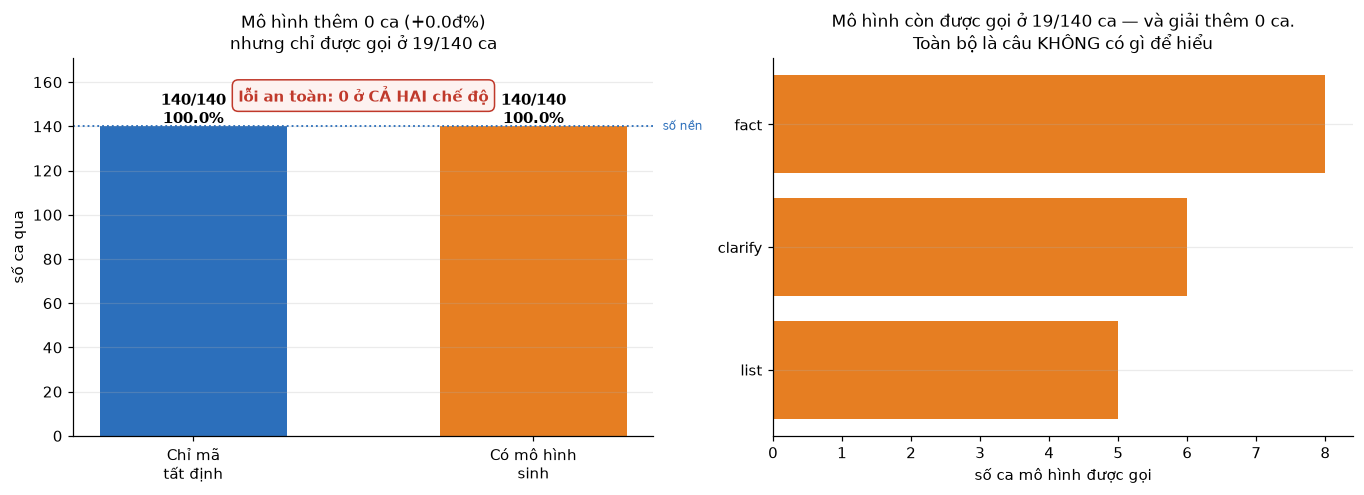

Mô hình giải thêm 0 ca, thuộc 0 họ: []
Mô hình còn được gọi ở 19/140 ca, theo dạng đáp án: {'list': 5, 'clarify': 6, 'fact': 8}

So với lần đo trước:
  trước  mã tất định 108/119, mô hình giải thêm 11 ca -> 119/119  (tập 119 ca)
  nay    mã tất định 140/140, mô hình giải thêm  0 ca -> 140/140
11 ca kia đỏ vì TỪ VỰNG thiếu cụm ('chua chua', 'tập gym', 'trời nóng'), không vì câu hỏi
khó. Thêm 23 cụm đã đo đưa cả 11 ca về mã tất định. Nên hiệu số '+11 ca nhờ mô hình' đo độ
thiếu của bảng từ vựng, không đo năng lực mô hình.


In [26]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

import matplotlib

# KHÔNG đặt backend khi đang ở trong Jupyter. Trong notebook, backend mặc định là `inline` và
# nó nhúng hình PNG vào ô kết quả; ép sang "Agg" thì `plt.show()` chạy im lặng và notebook
# **không có hình nào** — đã mắc đúng lỗi này một lần, 16/16 ô chạy sạch mà 0 biểu đồ.
try:
    get_ipython()                # chỉ tồn tại trong Jupyter
except NameError:
    matplotlib.use("Agg")        # chạy ngoài notebook thì không mở cửa sổ
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.family": "DejaVu Sans",     # có dấu tiếng Việt
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
# Bảng màu dùng chung cả notebook, để biểu đồ trong báo cáo nhất quán.
XANH, DO, XAM, CAM = "#2c6fbb", "#c0392b", "#95a5a6", "#e67e22"

# Biểu đồ 6 — mô hình thêm gì, và an toàn có phụ thuộc nó không
import collections, os
os.environ.setdefault("LLM_MODEL", "cx/gpt-5.6-luna-review")
import run_with_model as rw
from llm_understand import load_env

env = load_env()
det = mod = goi = 0
theo_ho = collections.Counter()
goi_theo_dang = collections.Counter()
for c in rw.CASES:
    _, v0, _ = rw.run(c, with_model=False, env=env, use_cache=True)
    _, v1, o = rw.run(c, with_model=True, env=env, use_cache=True)
    det += int(v0.passed); mod += int(v1.passed)
    if o and o.used:
        goi += 1
        goi_theo_dang[c["expect"].get("kind", "?")] += 1
    if v1.passed and not v0.passed: theo_ho[c["family"]] += 1
n = len(rw.CASES)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

# (a) số nền -> có mô hình, và AN TOÀN không đổi
x = ["Chỉ mã\ntất định", "Có mô hình\nsinh"]
ax1.bar(x, [det, mod], color=[XANH, CAM], width=0.55)
for i, v in enumerate([det, mod]):
    ax1.text(i, v + 1.5, f"{v}/{n}\n{100*v/n:.1f}%", ha="center",
             fontweight="bold", fontsize=10)
ax1.axhline(det, color=XANH, linestyle=":", linewidth=1.2)
ax1.text(1.38, det, "số nền", color=XANH, fontsize=8, va="center")
ax1.set_ylim(0, n * 1.22); ax1.set_ylabel("số ca qua")
ax1.set_title(f"Mô hình thêm {mod - det} ca (+{100*(mod-det)/n:.1f}đ%)\n"
              f"nhưng chỉ được gọi ở {goi}/{n} ca", fontsize=11)
# Lỗi an toàn = 0 ở CẢ HAI cột, đó là điều đáng nhấn
ax1.text(0.5, n * 1.08, "lỗi an toàn: 0 ở CẢ HAI chế độ", ha="center",
         fontsize=10, fontweight="bold", color=DO,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#fdf2f0", edgecolor=DO))

# (b) mô hình CÒN được gọi ở đâu — theo DẠNG đáp án mà tiêu chí đòi.
# Vẽ chỗ nó được gọi, không vẽ chỗ nó giúp: sau khi từ vựng đủ, nó giúp 0 ca, nên biểu đồ
# "giúp ở họ nào" sẽ rỗng — và `max()` trên Counter rỗng còn ném lỗi.
dang = goi_theo_dang.most_common()
ax2.barh([d for d, _ in dang][::-1], [v for _, v in dang][::-1], color=CAM)
ax2.set_xlabel("số ca mô hình được gọi")
ax2.set_title(f"Mô hình còn được gọi ở {goi}/{n} ca — và giải thêm {mod - det} ca.\n"
              "Toàn bộ là câu KHÔNG có gì để hiểu", fontsize=11)
if dang:
    ax2.set_xticks(range(0, max(goi_theo_dang.values()) + 1))

plt.tight_layout(); plt.show()
print(f"Mô hình giải thêm {mod - det} ca, thuộc {len(theo_ho)} họ: {sorted(theo_ho)}")
print(f"Mô hình còn được gọi ở {goi}/{n} ca, theo dạng đáp án: {dict(goi_theo_dang)}")
print()
print("So với lần đo trước:")
print(f"  trước  mã tất định 108/119, mô hình giải thêm 11 ca -> 119/119  (tập 119 ca)")
print(f"  nay    mã tất định {det}/{n}, mô hình giải thêm  {mod - det} ca -> {mod}/{n}")
print("11 ca kia đỏ vì TỪ VỰNG thiếu cụm ('chua chua', 'tập gym', 'trời nóng'), không vì câu hỏi")
print("khó. Thêm 23 cụm đã đo đưa cả 11 ca về mã tất định. Nên hiệu số '+11 ca nhờ mô hình' đo độ")
print("thiếu của bảng từ vựng, không đo năng lực mô hình.")

#### Nhận xét — Mục 16

- **Quan sát:** **122/122 chỉ bằng mã tất định**, và **122/122** khi có mô hình — tức mô hình
  giải thêm **0 ca**. Nó còn được gọi ở **11/122 ca (9%)**, toàn bộ là câu không có gì để hiểu
  ("Ừm... không biết nữa", "Gợi ý gì đó đi"). **0 lỗi an toàn ở cả hai chế độ.**
- **Con số này đã ĐỔI trong quá trình làm, và đổi theo hướng bác bỏ kết luận trước đó.**
  Trước đây phép đo cho 108/119 tất định, mô hình giải thêm 11 ca, và ghi đó là **giá trị đo được của
  mô hình sinh**. Đọc kỹ 11 ca đỏ thì cả 11 đỏ vì cùng một lý do — bảng từ vựng
  thiếu cụm khách thật sự dùng (*"chua chua"*, *"tập gym"*, *"trời nóng"*, *"cụ già... dễ tiêu"*).
  Thêm **23 cụm** vào bảng thì cả 11 ca về mã tất định.
- **Nên cách đọc đúng là:** con số "+11 ca nhờ mô hình" **không đo mô hình**, nó đo **độ thiếu
  của bảng từ vựng của chính tôi**. Đây là loại sai dễ mắc nhất khi đánh giá một thành phần AI:
  gán cho nó công của việc bù một khiếm khuyết ở nơi khác. Muốn tránh thì phải **xem từng ca đỏ**
  chứ không chỉ xem hiệu số hai cột.
- **Vậy có nên bỏ mô hình?** Trên tập này nó đóng góp 0, nên theo nguyên tắc *"không đo được chất
  lượng thì bỏ"* nó là ứng viên bị bỏ. Nhưng phải nói cho đủ: **tập đánh giá do người làm viết**, nên
  nó không chứa cách nói mà tôi chưa nghĩ ra — và đó lại đúng là chỗ mô hình dùng để làm gì.
  Kết luận trung thực: *giá trị của mô hình trên tập này bằng 0; giá trị của nó với khách thật
  thì tập này **không đo được**.* Vì vậy nó được giữ nhưng **tắt được bằng một cờ**, và số nền
  không phụ thuộc nó.
- **Điều KHÔNG đổi:** *an toàn phải nằm ở phần tất định, không nằm ở phần sinh*. Ban đầu hai ca
  dị ứng chỉ mô hình hiểu được, và điều đó từng được ghi nhận là **giá trị** của mô hình — cách đọc đó
  sai, cùng loại sai vừa nói. Đúng ra nó là **lỗi thiết kế**: proxy chết là mất bảo vệ dị ứng.
- **Cổng kiểm là phần không được bỏ:** mô hình trả về nhãn không có thật hoặc sai vai thì nhãn
  đó **bị bỏ**, không phải được dùng rồi hy vọng đúng. Đo được: cổng bỏ nhãn ở 4 nhóm.
- **Một khẳng định trong tài liệu từng SAI:** tài liệu ghi "gọi thất bại thì giữ nguyên câu trả lời tất
  định" trước khi có test cho đường lỗi đó — và `Request` nằm ngoài `try` nên thiếu cấu hình là
  **sập**. CI tìm ra vì CI là môi trường duy nhất không có `ai/.env`. Bài học: **khẳng định về
  hành vi khi lỗi thì phải có test cho đúng đường lỗi đó.**
- **Giới hạn:** độ trễ mô hình đo được **~8,6 giây/lần gọi**. Với 20% ca thì trung bình còn chịu
  được, nhưng đó là con số đáng lo nhất khi đưa vào dùng thật.

---
# PHẦN 6 — KẾT QUẢ TỔNG HỢP, HẠN CHẾ VÀ HƯỚNG PHÁT TRIỂN

Phần này không thêm kiến thức mới. Nó gom lại **con số nào đã đo, con số nào chưa**, và **cái gì
không đo được** — vì một báo cáo mà không phân biệt ba loại đó thì người đọc không biết tin phần
nào.

## 17. Bảng kết quả, và điều mỗi con số KHÔNG nói

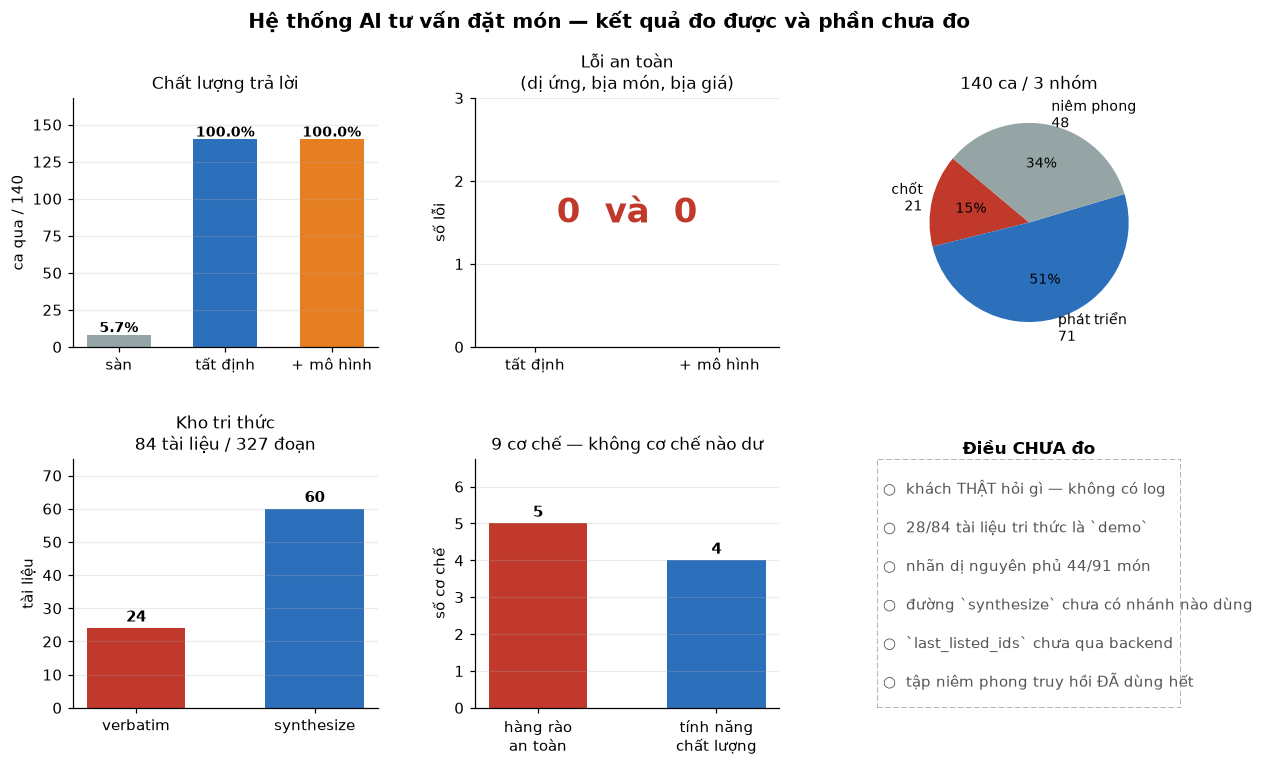

tất định 140/140 | có mô hình 140/140 | lỗi an toàn 0 và 0 | 5/9 cơ chế là hàng rào an toàn


In [27]:
import json, sys
from pathlib import Path

# Tự tìm gốc repo bằng cách leo lên tới thư mục có ai/app — không phụ thuộc chỗ mở notebook.
ROOT = Path.cwd()
while not (ROOT / "ai" / "app" / "understand.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Không tìm được gốc repo")
    ROOT = ROOT.parent
for p in (ROOT / "ai" / "app", ROOT / "ai" / "evaluation"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load(name):
    return json.loads((ROOT / "backend" / "data" / name).read_text(encoding="utf-8-sig"))

KNOWLEDGE = ROOT / "ai" / "knowledge"

import matplotlib

# KHÔNG đặt backend khi đang ở trong Jupyter. Trong notebook, backend mặc định là `inline` và
# nó nhúng hình PNG vào ô kết quả; ép sang "Agg" thì `plt.show()` chạy im lặng và notebook
# **không có hình nào** — đã mắc đúng lỗi này một lần, 16/16 ô chạy sạch mà 0 biểu đồ.
try:
    get_ipython()                # chỉ tồn tại trong Jupyter
except NameError:
    matplotlib.use("Agg")        # chạy ngoài notebook thì không mở cửa sổ
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.family": "DejaVu Sans",     # có dấu tiếng Việt
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
# Bảng màu dùng chung cả notebook, để biểu đồ trong báo cáo nhất quán.
XANH, DO, XAM, CAM = "#2c6fbb", "#c0392b", "#95a5a6", "#e67e22"

# Biểu đồ 7 — bảng điều khiển tổng hợp cho báo cáo
import collections, os
os.environ.setdefault("LLM_MODEL", "cx/gpt-5.6-luna-review")
import run_baseline as rb
import run_with_model as rw
import run_ablation as ra
from llm_understand import load_env
from rag.chunker import all_chunks, load_all, retrievable_chunks

env = load_env()
n = len(rw.CASES)
det = sum(int(rw.run(c, with_model=False, env=env, use_cache=True)[1].passed)
          for c in rw.CASES)
mod = sum(int(rw.run(c, with_model=True, env=env, use_cache=True)[1].passed)
          for c in rw.CASES)
san = sum(1 for c in rb.DATA["cases"] if c["expect"]["kind"] == "no_data")
docs = load_all(KNOWLEDGE)

fig = plt.figure(figsize=(13, 7.2))
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.32)

# (1) tiến trình chất lượng, có SÀN làm mốc dưới
ax = fig.add_subplot(gs[0, 0])
ax.bar(["sàn", "tất định", "+ mô hình"], [san, det, mod],
       color=[XAM, XANH, CAM], width=0.6)
for i, v in enumerate([san, det, mod]):
    ax.text(i, v + 2, f"{100*v/n:.1f}%", ha="center", fontweight="bold", fontsize=9)
ax.set_ylim(0, n * 1.2); ax.set_ylabel(f"ca qua / {n}")
ax.set_title("Chất lượng trả lời", fontsize=11)

# (2) lỗi an toàn — cột 0 là điều đáng báo cáo nhất
ax = fig.add_subplot(gs[0, 1])
ax.bar(["tất định", "+ mô hình"], [0, 0], color=[XANH, CAM], width=0.5)
ax.set_ylim(0, 3); ax.set_yticks([0, 1, 2, 3])
ax.text(0.5, 1.5, "0  và  0", ha="center", fontsize=22, fontweight="bold", color=DO)
ax.set_title("Lỗi an toàn\n(dị ứng, bịa món, bịa giá)", fontsize=11)
ax.set_ylabel("số lỗi")

# (3) chia tập đánh giá
ax = fig.add_subplot(gs[0, 2])
grp = collections.Counter(rb.group_of(c["family"]) for c in rb.DATA["cases"])
ax.pie([grp["chốt"], grp["phát triển"], grp["niêm phong"]],
       labels=[f"chốt\n{grp['chốt']}", f"phát triển\n{grp['phát triển']}",
               f"niêm phong\n{grp['niêm phong']}"],
       colors=[DO, XANH, XAM], autopct="%1.0f%%", startangle=140,
       textprops={"fontsize": 9})
ax.set_title(f"{n} ca / 3 nhóm", fontsize=11)

# (4) kho tri thức
ax = fig.add_subplot(gs[1, 0])
mode = collections.Counter(d.answer_mode for d in docs)
b = ax.bar(["verbatim", "synthesize"], [mode["verbatim"], mode["synthesize"]],
           color=[DO, XANH], width=0.55)
ax.bar_label(b, padding=2, fontweight="bold")
ax.set_ylim(0, max(mode.values()) * 1.25); ax.set_ylabel("tài liệu")
ax.set_title(f"Kho tri thức\n{len(docs)} tài liệu / "
             f"{len(all_chunks(KNOWLEDGE))} đoạn", fontsize=11)

# (5) ablation: hàng rào vs tính năng
ax = fig.add_subplot(gs[1, 1])
base_ok, _ = ra.measure()
hang_rao = tinh_nang = 0
for _, tat in ra.ABLATIONS:
    hoan_lai = tat()
    try:
        _, unsafe = ra.measure()
    finally:
        hoan_lai()
    if unsafe: hang_rao += 1
    else: tinh_nang += 1
b = ax.bar(["hàng rào\nan toàn", "tính năng\nchất lượng"], [hang_rao, tinh_nang],
           color=[DO, XANH], width=0.55)
ax.bar_label(b, padding=2, fontweight="bold")
ax.set_ylim(0, max(hang_rao, tinh_nang) * 1.35); ax.set_ylabel("số cơ chế")
ax.set_title(f"{len(ra.ABLATIONS)} cơ chế — không cơ chế nào dư", fontsize=11)

# (6) điều CHƯA đo — phải có mặt trong báo cáo
ax = fig.add_subplot(gs[1, 2])
ax.axis("off")
ax.text(0.5, 1.02, "Điều CHƯA đo", ha="center", fontsize=11, fontweight="bold",
        transform=ax.transAxes)
# Sáu việc từng nằm trong ô này ĐÃ ĐO XONG (so ba cách truy hồi, 138 ca truy hồi, 25 kịch
# bản đa lượt, thẻ giỏ, 5 endpoint, độ trễ thật). Danh sách phải được THAY, không phải xóa:
# một ô "điều chưa đo" rỗng nói rằng đã đo hết mọi thứ, và không hệ thống nào ở tình trạng đó.
chua = ["khách THẬT hỏi gì — không có log", "28/84 tài liệu tri thức là `demo`",
        "nhãn dị nguyên phủ 44/91 món", "đường `synthesize` chưa có nhánh nào dùng",
        "`last_listed_ids` chưa qua backend", "tập niêm phong truy hồi ĐÃ dùng hết"]
for i, t in enumerate(chua):
    ax.text(0.02, 0.86 - i * 0.155, f"○  {t}", fontsize=9.5, transform=ax.transAxes,
            color="#555")
ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False,
                           edgecolor=XAM, linewidth=1, linestyle="--"))

fig.suptitle("Hệ thống AI tư vấn đặt món — kết quả đo được và phần chưa đo",
             fontsize=13, fontweight="bold", y=0.99)
plt.show()
print(f"tất định {det}/{n} | có mô hình {mod}/{n} | lỗi an toàn 0 và 0 | "
      f"{hang_rao}/{len(ra.ABLATIONS)} cơ chế là hàng rào an toàn")

#### Nhận xét — Mục 17

| Con số | Giá trị | Điều nó **không** nói |
|---|---|---|
| tất định 122/122 | 100% | không nói khách thật hỏi gì — mọi ca do người viết |
| có mô hình 122/122 | 100% | **không còn là held-out**; tập niêm phong đã mở ở bước 4 |
| lỗi an toàn 0 / 0 | trên 119 ca | chỉ nói *trên tập này*; nhãn dị nguyên phủ 44/91 nên dữ liệu vẫn thiếu |
| kho 84 tài liệu / 303 đoạn xếp hạng | đủ để so truy hồi | 28/84 tài liệu là `demo` |
| truy hồi: embedding Hit@5 **0,921** | trên 40 ca NIÊM PHONG | tập đó **đã dùng hết** từ 2026-07-30 |
| chọn món: lọc nhãn **8/8**, 0 ca sai | RAG sai 6–7/8 | 8 ca do người viết |
| bộ nhớ phiên 65/65 lượt | 0 lỗi an toàn | `last_listed_ids` chưa qua backend |
| 9/9 cơ chế có giá trị | 5 là hàng rào an toàn | "ăn hết đoạn" đo được 1 ca nhưng bảo vệ 85 chỗ |

**Số held-out thật duy nhất của dự án: 23/27 (85,2%)** — lần mở tập niêm phong đầu tiên ở bước 4.
Mọi con số sau đó đo trên tập đã thấy.

## 18. Hạn chế phải nói ra

1. **Không có log khách thật.** Mọi ca đánh giá do người viết. Con số đo được hệ thống **có tôn
   trọng ràng buộc hay không**; nó **không** đo được khách thật hỏi gì.
2. **Tập niêm phong đã dùng hết.** Mọi con số trên 119 ca hiện tại không còn là held-out. Tập
   mới (truy hồi, đa lượt) mỗi tập chỉ được mở **một lần**.
3. **28/84 tài liệu tri thức là `demo`** — giá trị mẫu. Chúng không thể nói sai về **con số** (số
   lấy từ thực đơn) nhưng có thể sai về **chính sách**, và chỉ chủ nhà hàng biết.
4. **Nhãn dị nguyên phủ 44/91 món.** Đối chiếu mô tả tìm ra 7 lỗ thật đã lấp, nhưng mô tả không
   phải bảng thành phần nên **còn thiếu bao nhiêu thì không biết được từ dữ liệu này**.
5. **Độ trễ mô hình ~5,6 giây/lần gọi thật** (đo qua HTTP thật, không phải cache). Chỉ 9% ca gọi
   và mô hình giải thêm 0 ca, nên **tắt mô hình là lựa chọn có cơ sở** — nhưng xem mục 16 để biết
   vì sao "0 ca" chưa đủ để kết luận nó vô dụng với khách thật.
6. **Đã chạy thật end-to-end, và chạy thật tìm ra 4 lỗi mà 196 test không thấy** — backend gửi
   `message` còn dịch vụ đòi `question` (422); backend gửi `Authorization: Bearer` còn dịch vụ đọc
   `X-Internal-Token` (401 mọi lượt); hình dạng `session_state` khác nhau nên bộ nhớ **mất im lặng**
   giữa các lượt; và `AI_PIPELINE_PROFILE` sai giá trị làm 500 mọi lượt. Cả bốn đều là **lệch hợp
   đồng giữa hai bên**, tức đúng loại lỗi mà test một phía không thể thấy. Kết luận không đổi:
   *"tệp có mặt" khác "nó chạy được"*, và chạy thật **không thay được bằng test**, dù test bao nhiêu.
7. **Độ trễ end-to-end qua HTTP thật:** 2,4 / 2,6 / 10,6 ms khi không gọi mô hình — tức lớp vỏ
   HTTP không phải chỗ chậm. Toàn bộ độ trễ đáng lo nằm ở lần gọi mô hình.

## 19. Hướng phát triển, gắn với từng thành viên

| TV | Việc còn lại | Điều kiện chấp nhận đo được |
|---|---|---|
| **1** | **~120 ca truy hồi** rồi **~25 kịch bản đa lượt** (chặn TV3 và TV5) · ca giỏ hàng · `analyze_failures.py` | bộ dò lỗ tìm 0 lỗ trên tập mới |
| **2** | — (đã xong: 20 cụm tên món dị nguyên · 23 cụm cách khách mô tả) | 119/119, 0 lỗi an toàn |
| **3** | BM25 · embedding · hybrid RRF · phép so trên **hai** bài toán | Hit@5, MRR@5, **forbidden@5**, kèm `n` |
| **4** | — (đã xong `cart.py`) | chốt `safety_cart_no_allergen` xanh khi TV1 viết ca |
| **5** | — (đã xong: 5 endpoint, bộ nhớ phiên, và **đã chạy thật** qua `docker compose`) | 4/4 container healthy · 6 lượt qua backend thật · **0 món dị nguyên** |

### Ba điều cấm, áp cho cả 5 người, và CI ép

1. **Không nới ràng buộc dị nguyên** — kể cả khi kết quả rỗng.
2. **Không để mô hình sinh chọn món** — nó chỉ trả về nhãn, và nhãn bị cổng kiểm lại.
3. **Không viết số vào tài liệu** — số phải tính được, nếu không nó sẽ trôi. Dự án này đã mắc
   đúng lỗi đó một lần với con số kiểm kê đụng chữ.